# Import Libraries and Define Functions

In [1]:
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import plotly.express as px                                                                                                             
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
  
pio.renderers.default = "svg"
pio.renderers["svg"].width = 1100      
pio.renderers["svg"].scale = 2         

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.labelsize": 10, "axes.edgecolor": "#888888",
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.dpi": 100,
})

def nice(s):                    
    return s.replace("_", " ").title()

def si(x, _pos=None):           
    a = abs(x)
    if a >= 1e9: return f"{x/1e9:.1f}B"
    if a >= 1e6: return f"{x/1e6:.1f}M"
    if a >= 1e3: return f"{x/1e3:.0f}K"
    return f"{x:.0f}"

def si_money(x, _pos=None):
    return "$" + si(x)

SI = FuncFormatter(si)
SI_MONEY = FuncFormatter(si_money)
ACCENT, ACCENT2 = "#2C7FB8", "#D95F0E"


# Load Data

In [2]:
crm_implants = pd.read_csv("./data/crm_implants.csv")
crm_sales = pd.read_csv("./data/crm_sales.csv")
targets_data = pd.read_csv("./data/targets_data.csv")
column_desc = pd.read_excel("./data/readme.xlsx")

# Exploratory Data Analysis

### CRM Implants

In [3]:
NA_TOKENS = ["", " ", "None", "none", "NONE", "NaN", "nan", "NAN", "N/A", "n/a", "NA", "null", "NULL", "-"]

crm_implants = crm_implants.astype(str).apply(lambda s: s.str.strip()).replace(NA_TOKENS, np.nan)
print(crm_implants.isna().sum())

fiscal_year                  0
area                         0
region_code                  0
territory                    0
hospital_id                  0
hospital_name                0
idn_name                     0
market_segment               0
city                         0
state                        0
rep_id                       0
rep_name                     0
rep_tier                     0
implanting_physician_id      0
implanting_physician_name    0
product_type                 0
product_hierarchy            0
model_name                   0
model_id                     0
serial_number                0
sales_order_number           0
implant_type                 0
dtype: int64


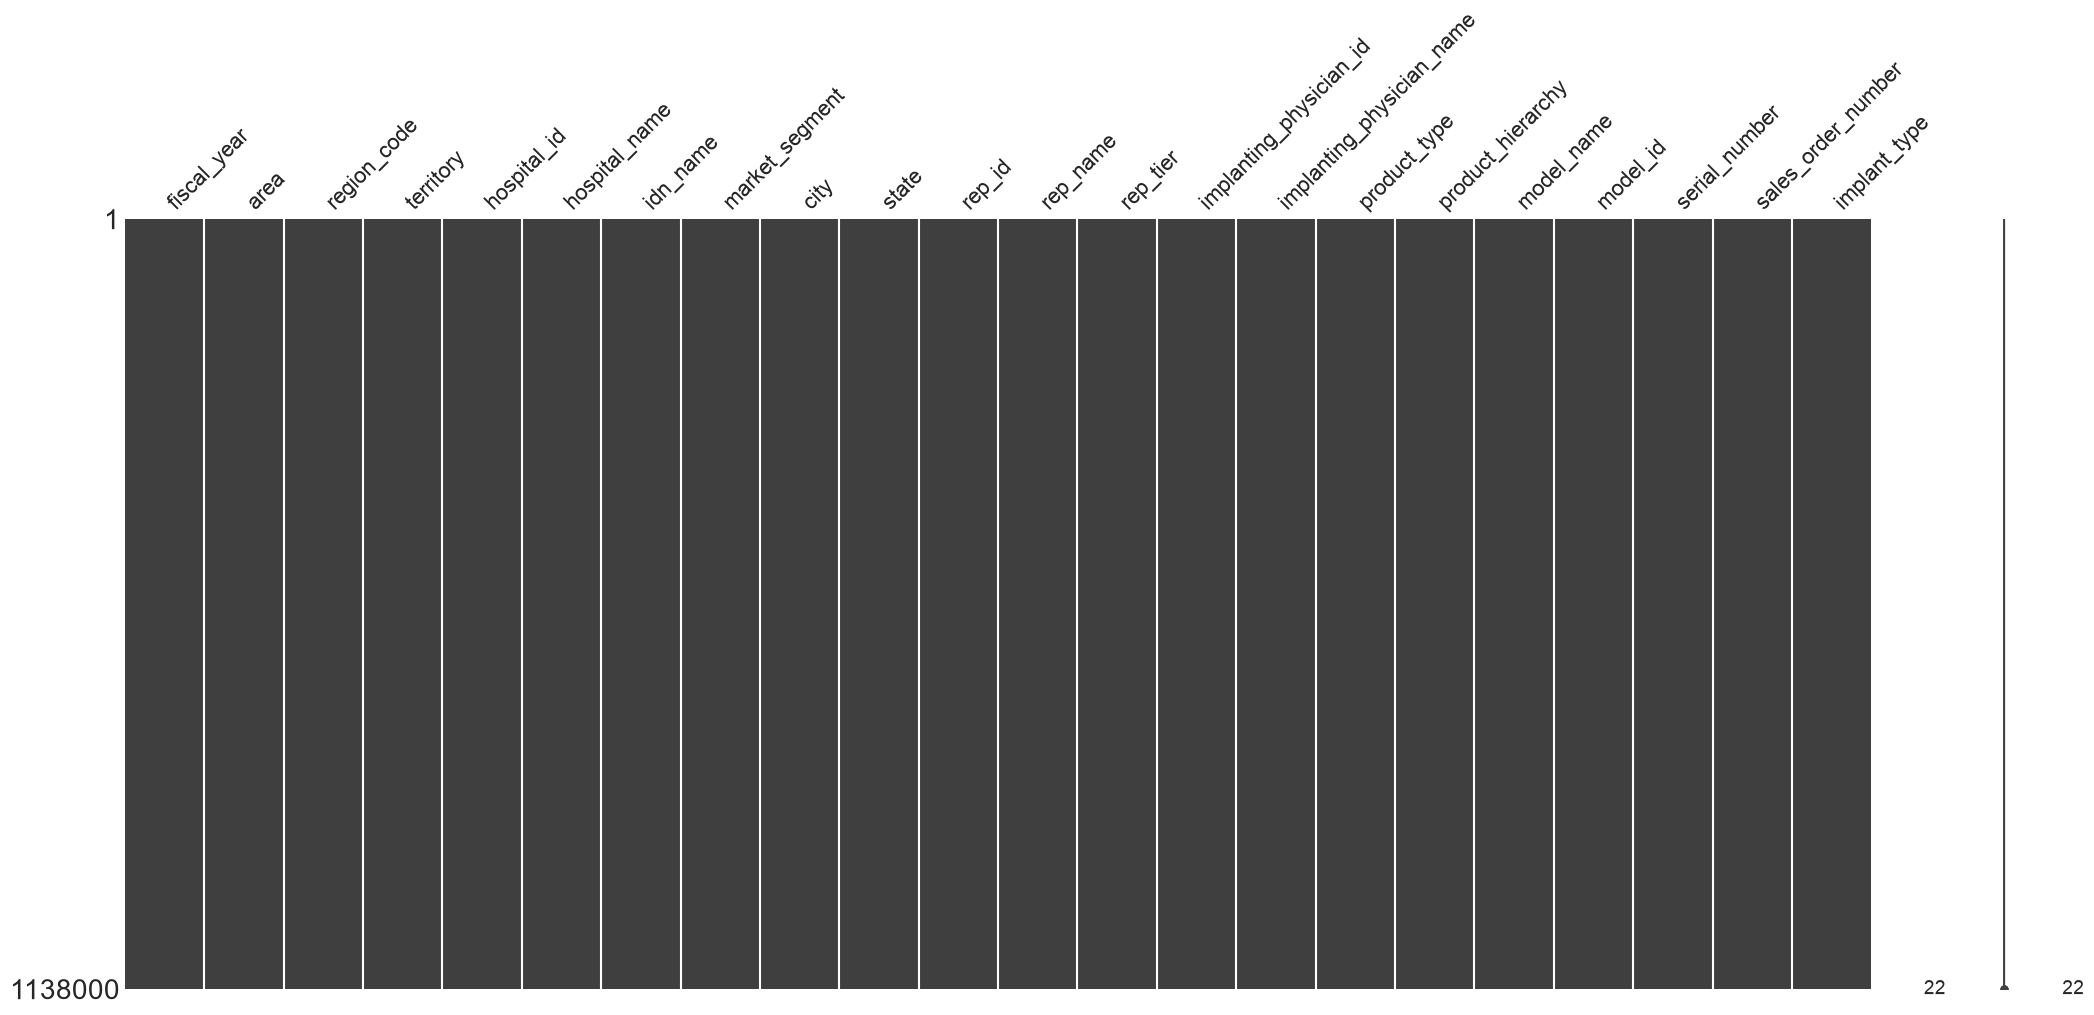

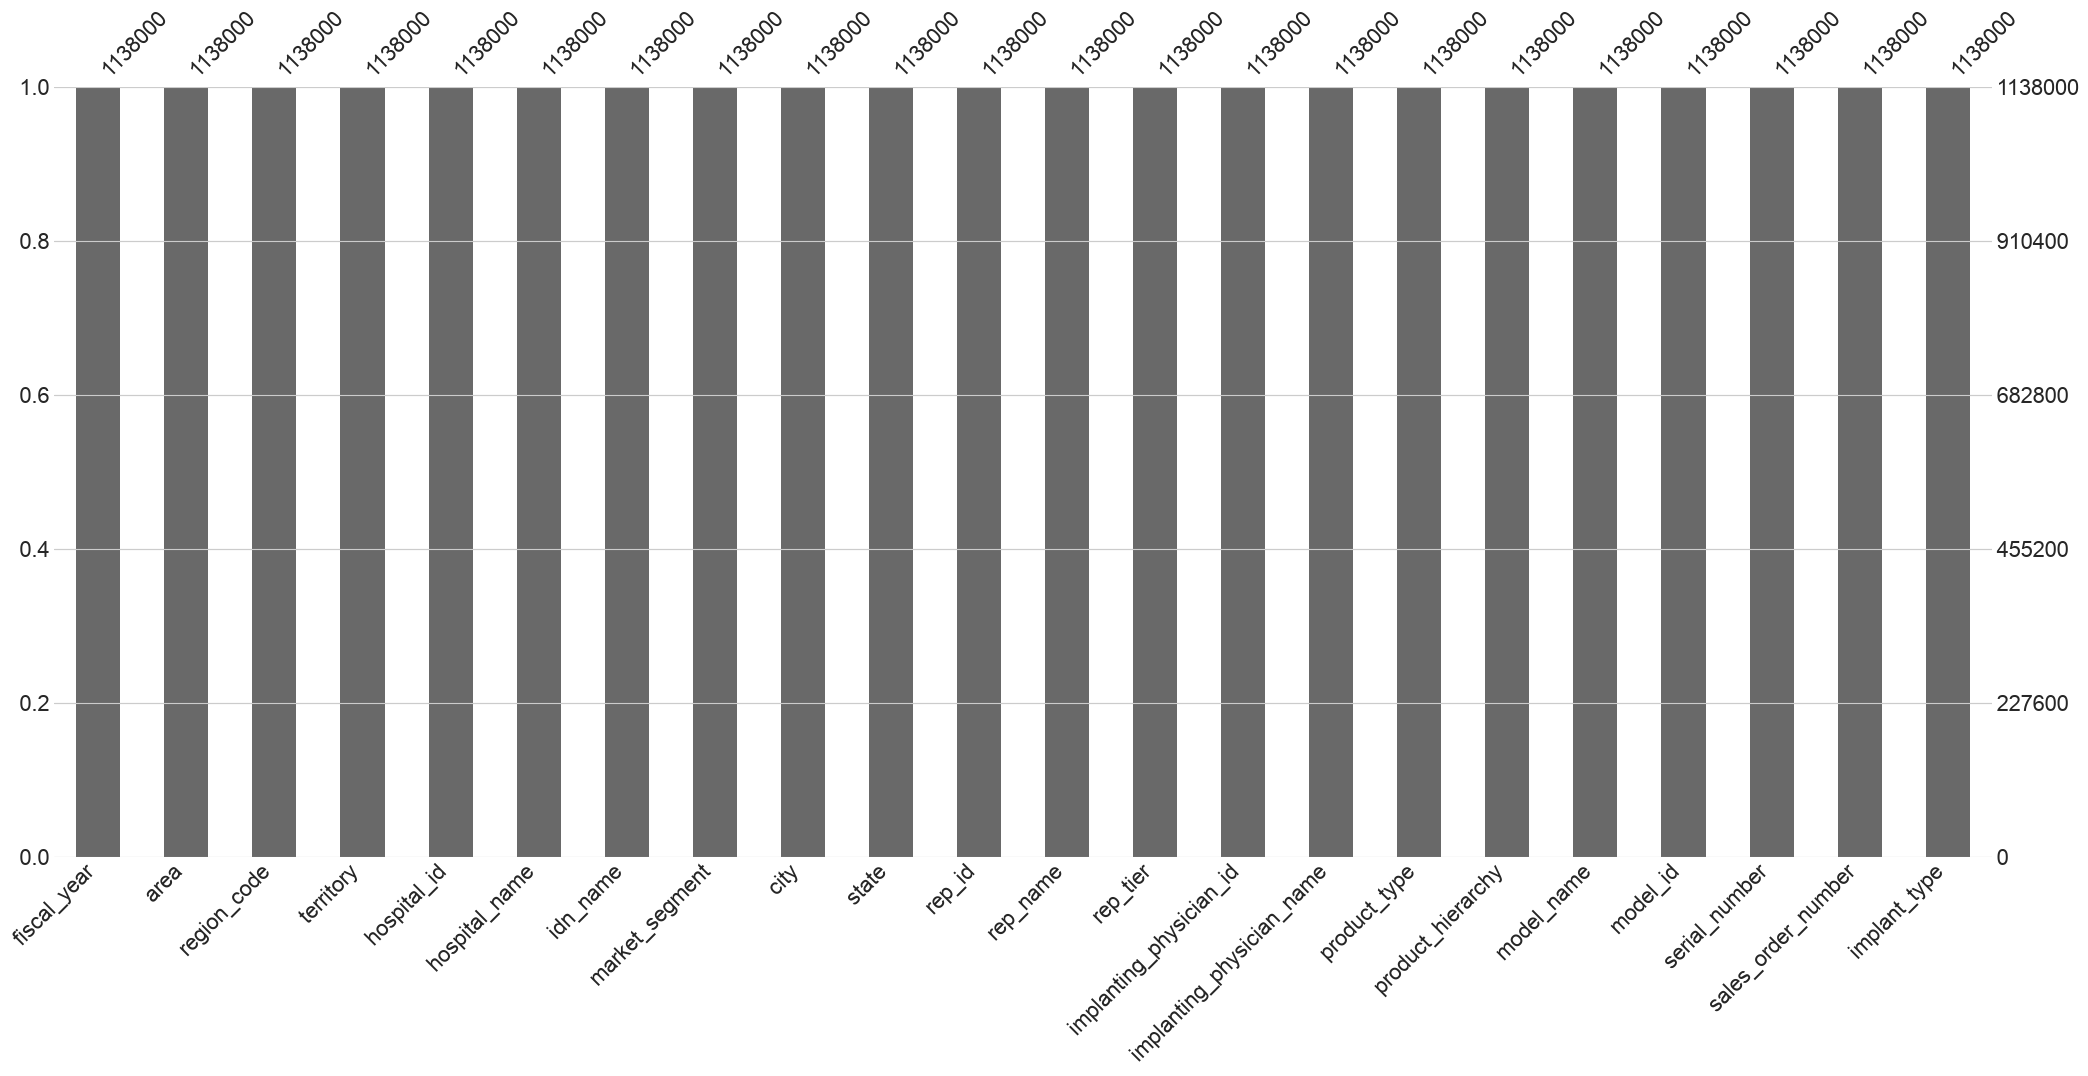

In [4]:
msno.matrix(crm_implants)
plt.show()
msno.bar(crm_implants); plt.show()

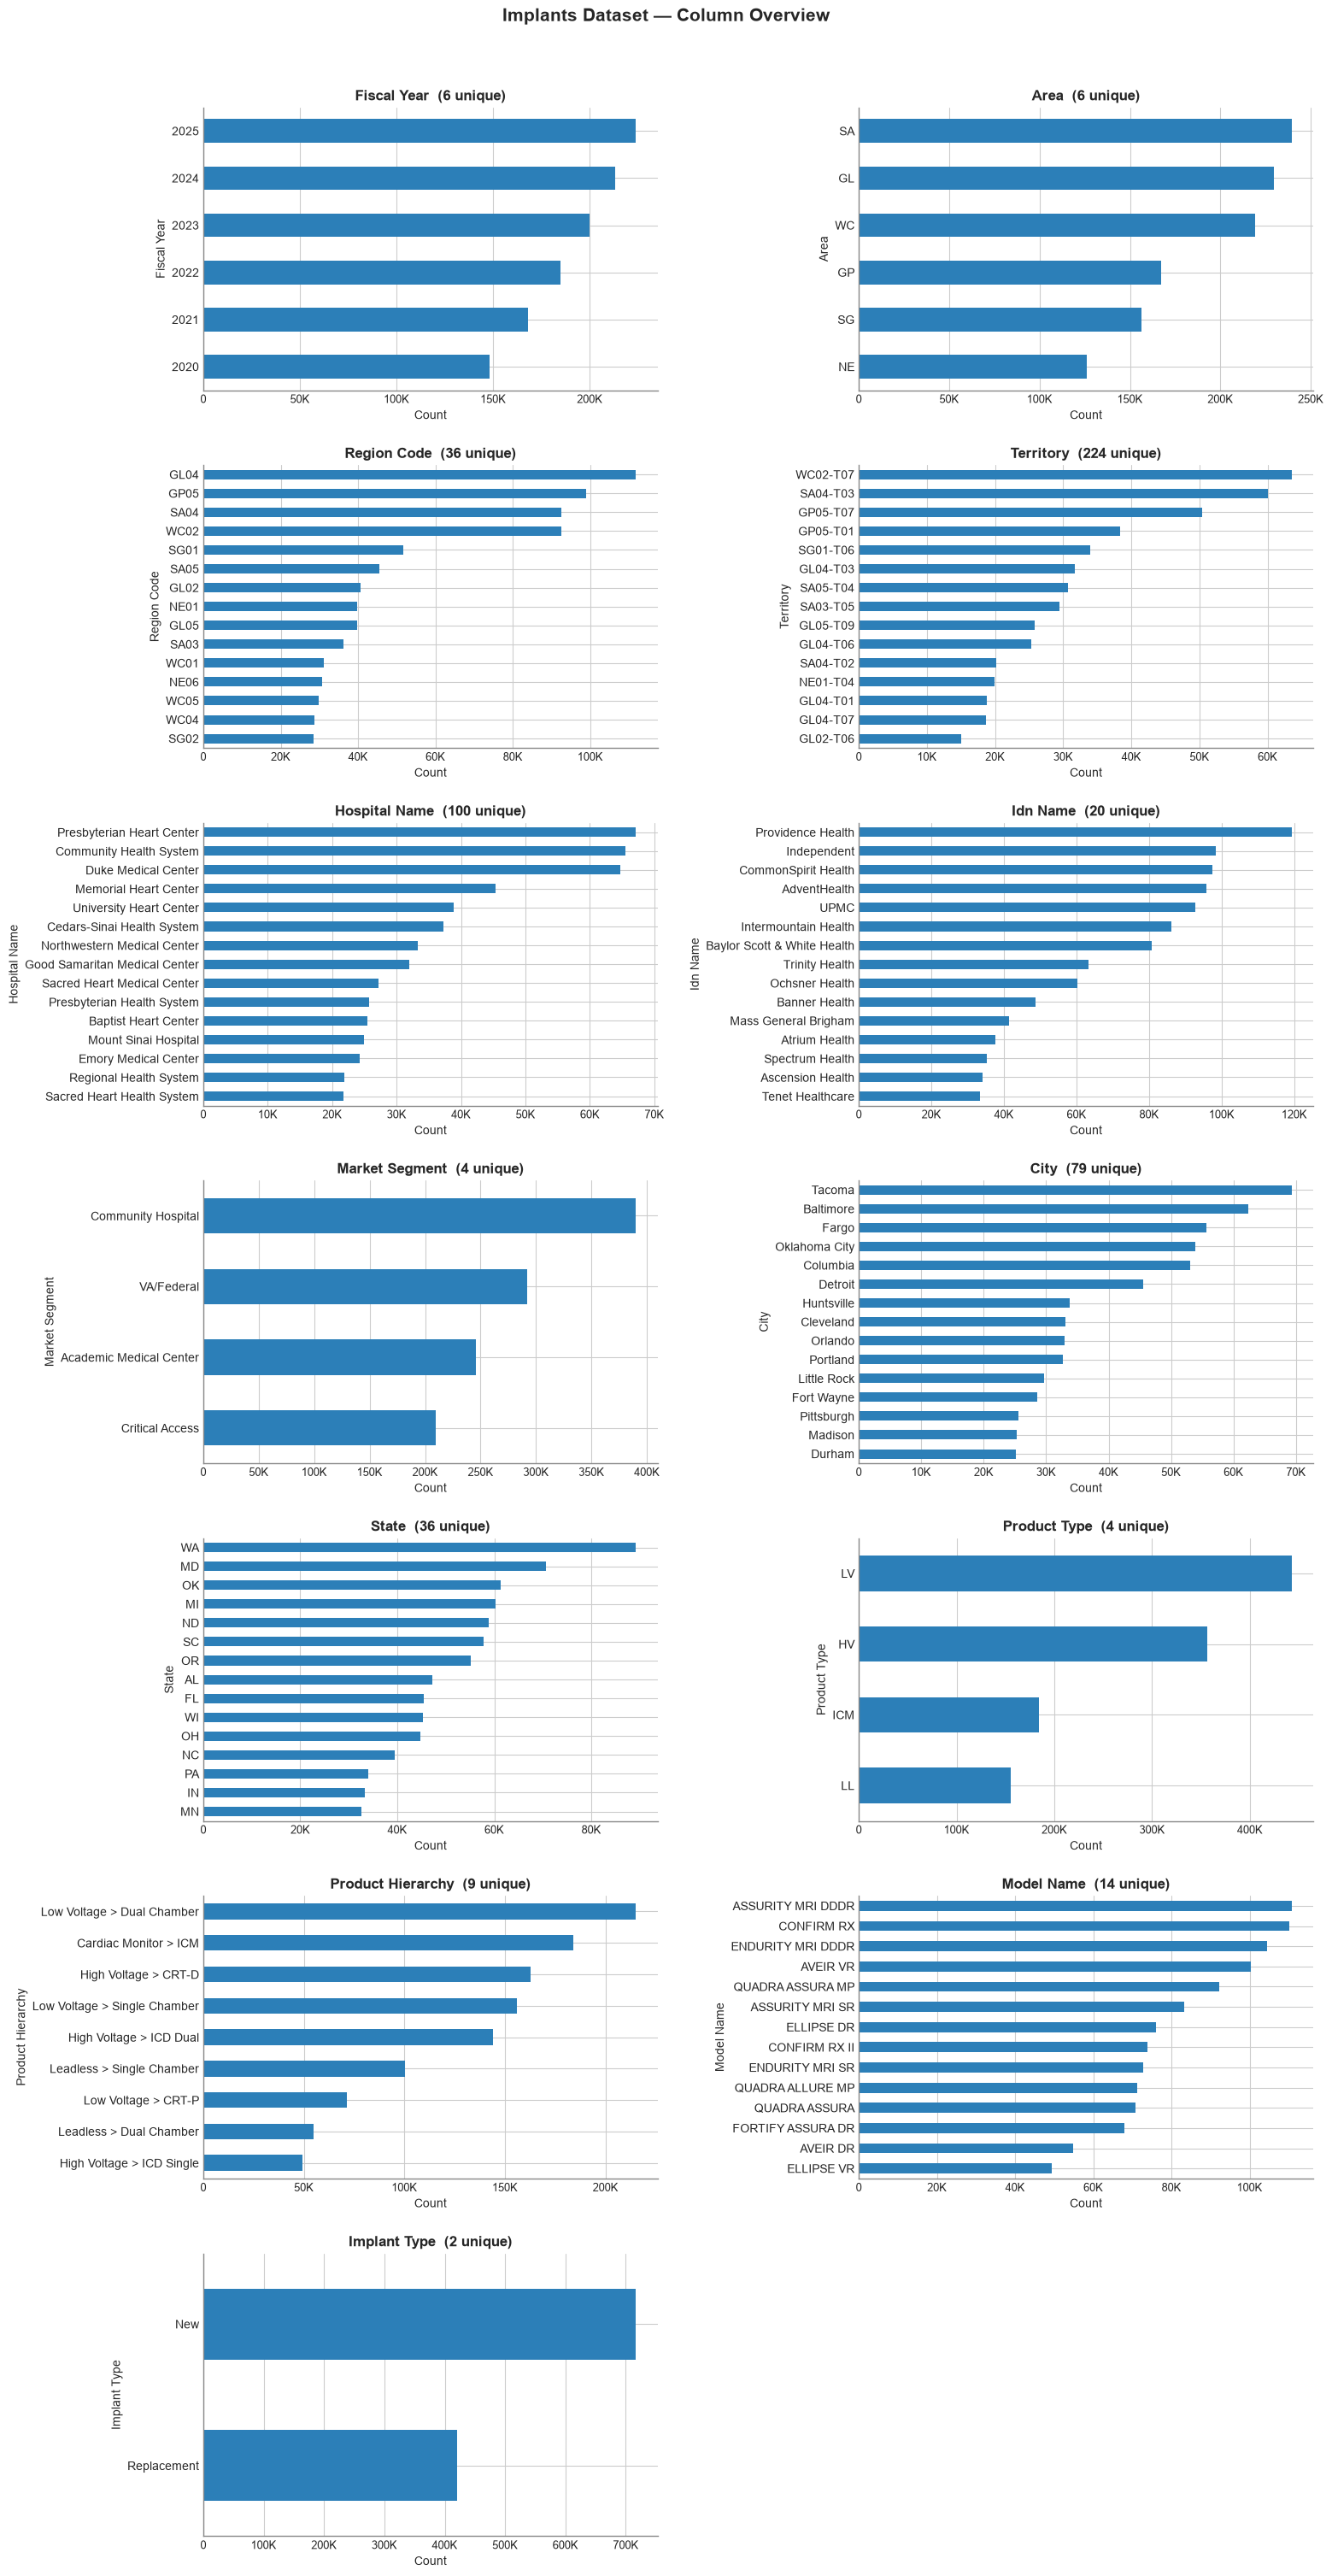

In [5]:
skip = ['serial_number', 'sales_order_number', 'hospital_id', 'implanting_physician_id',
        'implanting_physician_name', 'rep_id', 'rep_name', 'rep_tier', 'model_id']
cols = [c for c in crm_implants.columns if c not in skip]

ncols = 2
nrows = (len(cols) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4.3 * nrows))

for ax, col in zip(axes.flat, cols):
    vc = crm_implants[col].value_counts(dropna=False).head(15)
    vc.iloc[::-1].plot.barh(ax=ax, color=ACCENT)
    ax.set_title(f"{nice(col)}  ({crm_implants[col].nunique()} unique)")
    ax.set_xlabel("Count")
    ax.set_ylabel(nice(col))          # <-- fixes 'fiscal_year' -> 'Fiscal Year' on y-axis
    ax.tick_params(axis='x', labelsize=9)
    ax.xaxis.set_major_formatter(SI)

for ax in axes.flat[len(cols):]:
    ax.axis('off')

fig.suptitle("Implants Dataset — Column Overview", fontsize=15, fontweight="bold", y=1.005)
plt.tight_layout(pad=2.2)
plt.show()

### CRM Sales

In [6]:
crm_sales = crm_sales.astype(str).apply(lambda s: s.str.strip()).replace(NA_TOKENS, np.nan)
print(crm_sales.isna().sum())

fiscal_year                         0
fiscal_quarter                      0
fiscal_month                        0
sales_date                          0
area                                0
region_code                         0
territory                           0
hospital_id                         0
hospital_name                       0
idn_name                            0
market_segment                      0
gpo_affiliation                489640
city                                0
state                               0
rep_id                              0
rep_name                            0
rep_tier                            0
implanting_physician_id             0
product_type                        0
product_hierarchy                   0
model_name                          0
model_id                            0
channel                             0
contract_type                       0
gpo_contract_name             1428751
order_type                          0
days_to_clos

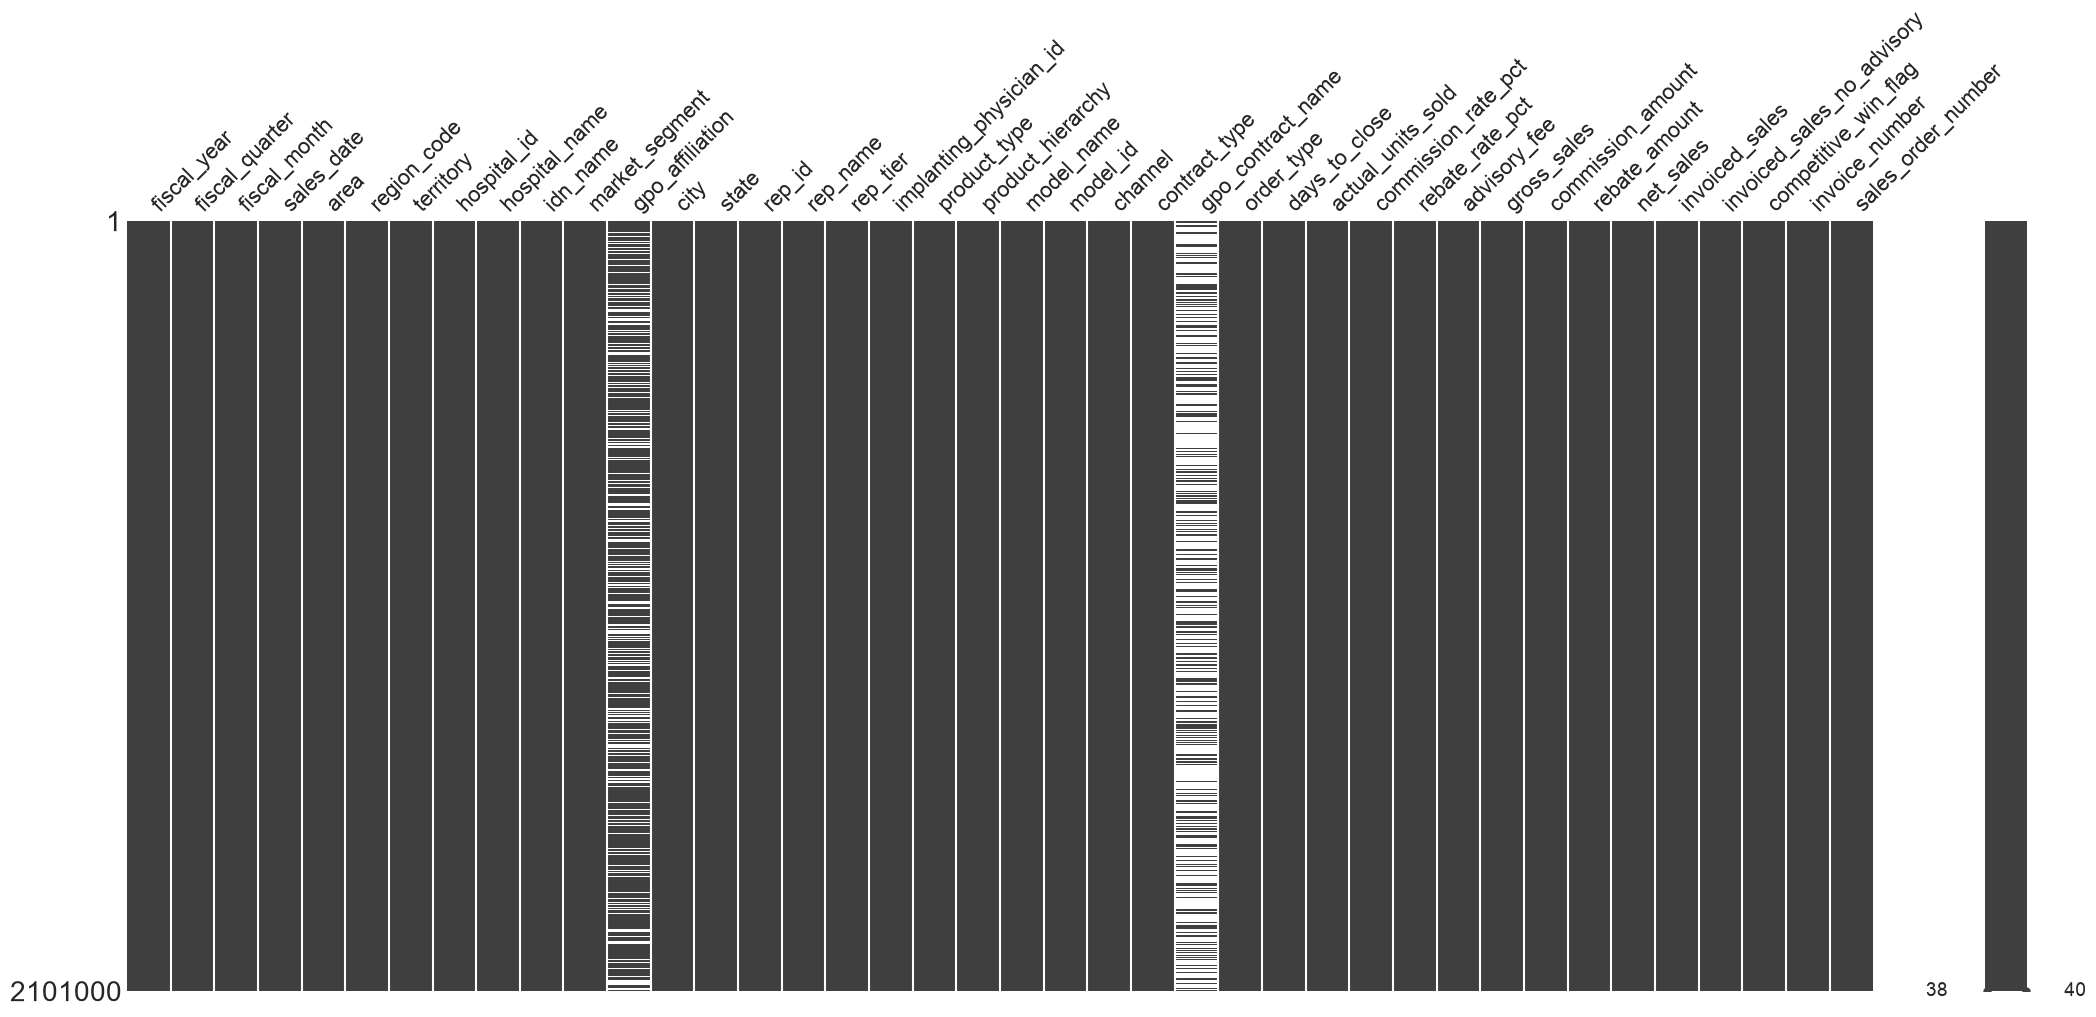

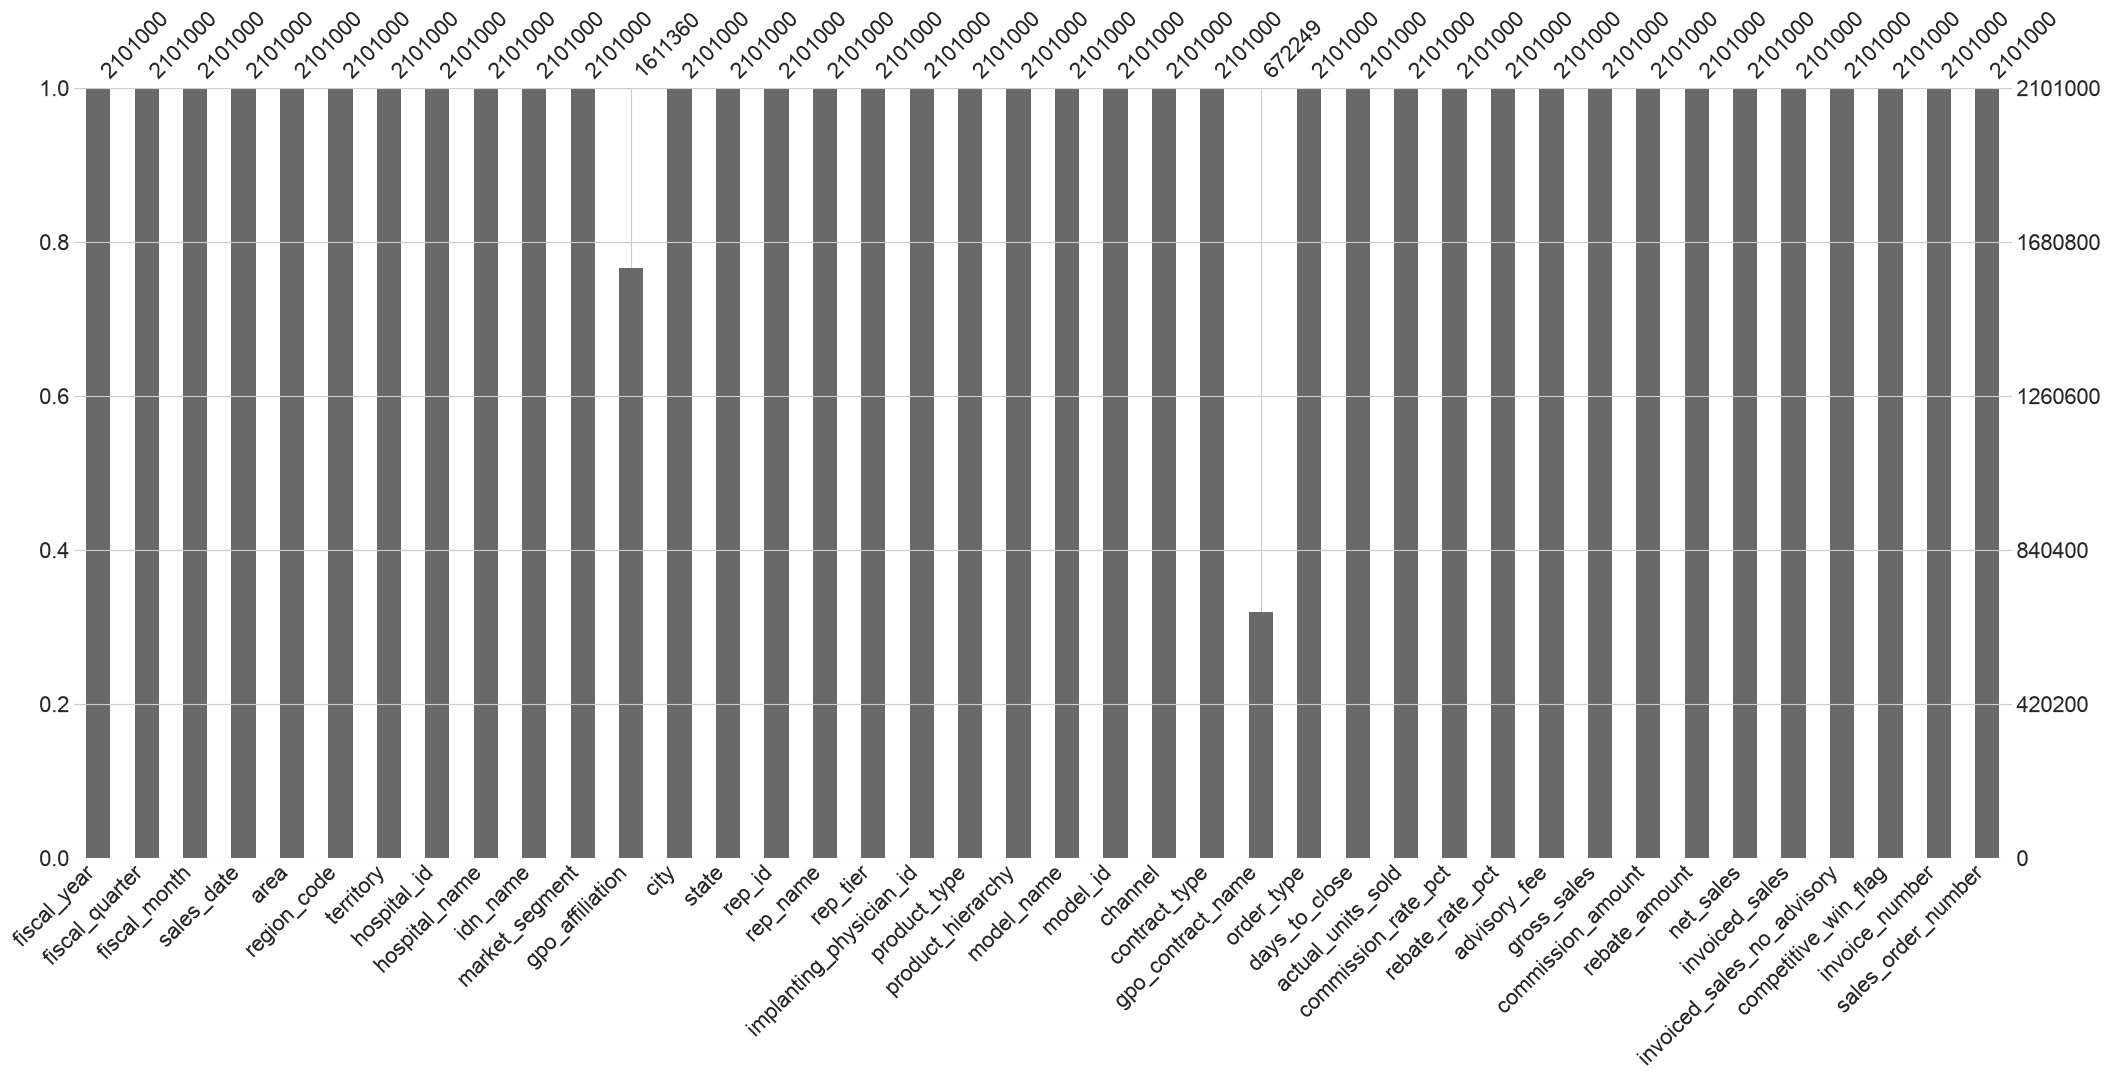

In [7]:
msno.matrix(crm_sales)
plt.show()
msno.bar(crm_sales); plt.show()

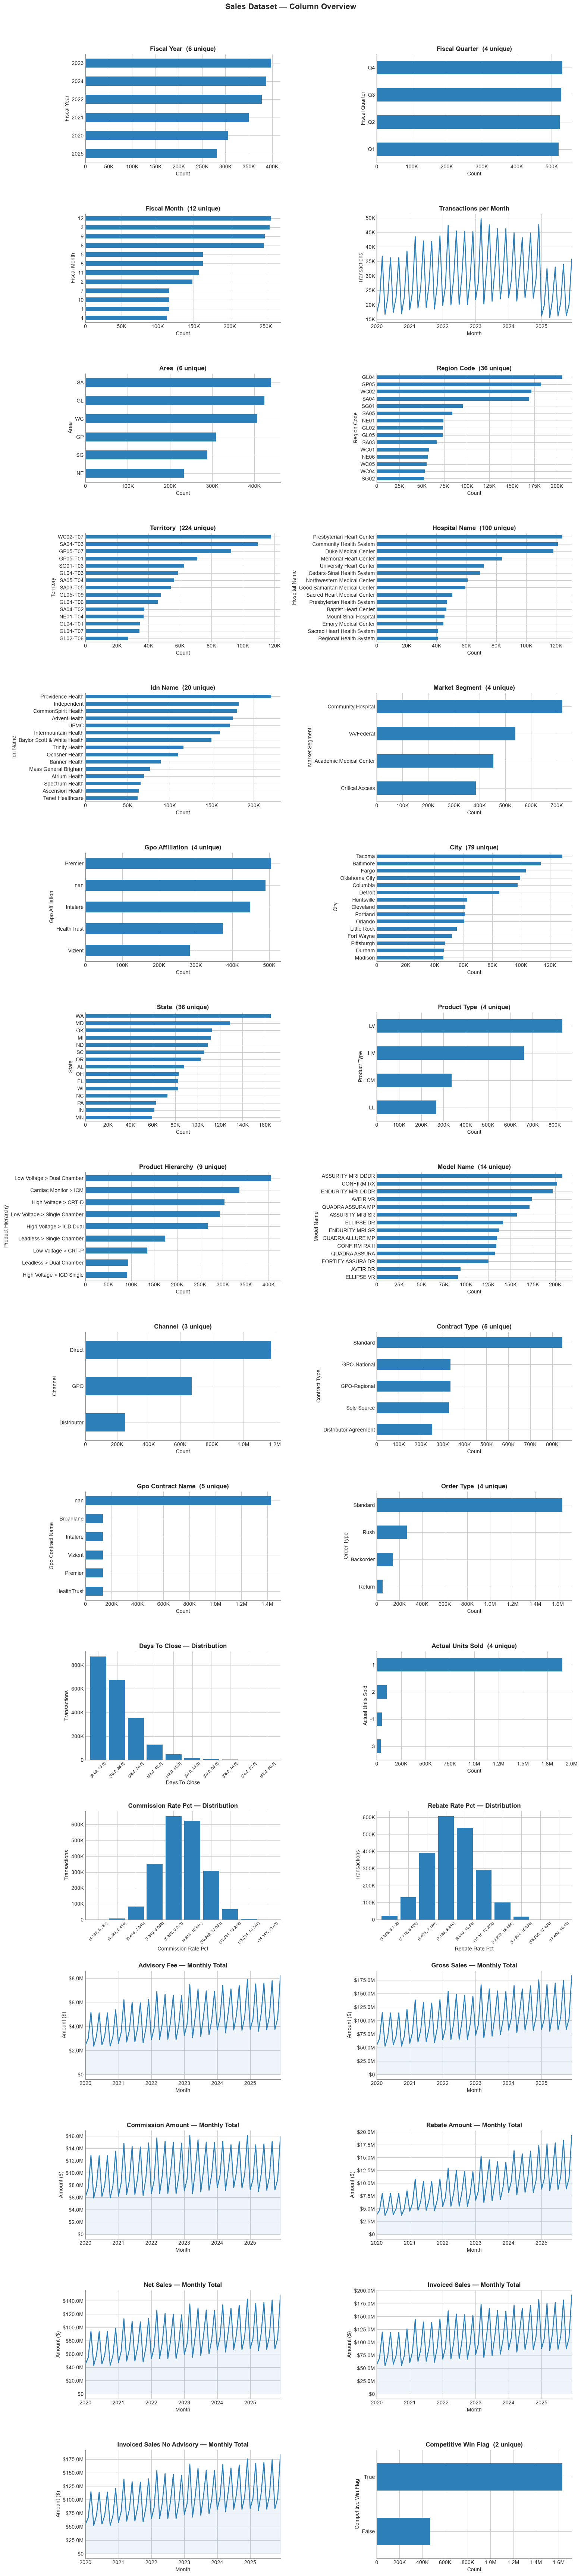

In [8]:
bucket_num  = ['days_to_close', 'commission_rate_pct', 'rebate_rate_pct']
bucket_date = ['sales_date']
timeseries  = ['commission_amount', 'advisory_fee', 'gross_sales', 'rebate_amount',
                'net_sales', 'invoiced_sales', 'invoiced_sales_no_advisory']
skip = ['hospital_id', 'rep_id', 'model_id', 'invoice_number', 'sales_order_number',
        'rep_name', 'rep_tier', 'implanting_physician_id', '']
cols = [c for c in crm_sales.columns if c not in skip]

month = pd.to_datetime(crm_sales['sales_date'], errors='coerce').dt.to_period('M').dt.to_timestamp()

ncols = 2
nrows = (len(cols) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4.3 * nrows))

for ax, col in zip(axes.flat, cols):
    if col in bucket_num:
        s = pd.to_numeric(crm_sales[col], errors='coerce')
        pd.cut(s, bins=10).value_counts().sort_index().plot.bar(ax=ax, color=ACCENT, width=0.85)
        ax.set_title(f"{nice(col)} — Distribution")
        ax.set_xlabel(nice(col)); ax.set_ylabel("Transactions")
        ax.yaxis.set_major_formatter(SI)
        ax.tick_params(axis='x', labelrotation=45, labelsize=7)

    elif col in bucket_date:  
        month.value_counts().sort_index().plot.line(ax=ax, color=ACCENT, lw=1.8)
        ax.set_title("Transactions per Month")
        ax.set_xlabel("Month"); ax.set_ylabel("Transactions")
        ax.yaxis.set_major_formatter(SI)

    elif col in timeseries:   
        s = pd.to_numeric(crm_sales[col], errors='coerce').groupby(month).sum()
        s.plot.line(ax=ax, color=ACCENT, lw=1.8)
        ax.fill_between(s.index, s.values, alpha=0.08, color=ACCENT)
        ax.set_title(f"{nice(col)} — Monthly Total")
        ax.set_xlabel("Month"); ax.set_ylabel("Amount ($)")
        ax.yaxis.set_major_formatter(SI_MONEY)

    else: 
        vc = crm_sales[col].value_counts(dropna=False).head(15)
        vc.iloc[::-1].plot.barh(ax=ax, color=ACCENT)
        ax.set_title(f"{nice(col)}  ({crm_sales[col].nunique()} unique)")
        ax.set_xlabel("Count")
        ax.set_ylabel(nice(col))         
        ax.xaxis.set_major_formatter(SI)

for ax in axes.flat[len(cols):]: 
    ax.axis('off')

fig.suptitle("Sales Dataset — Column Overview", fontsize=15, fontweight="bold", y=1.005)
plt.tight_layout(pad=2.2)
plt.show()

### Targets Data

In [9]:
targets_data = targets_data.astype(str).apply(lambda s: s.str.strip()).replace(NA_TOKENS, np.nan)
print(targets_data.isna().sum())

target_level                       2
fiscal_year                        2
area                               2
region_code                        2
territory                          2
entity_id                          2
rep_name                        3554
rep_tier                        3554
product_type                       2
annual_net_sales_target            0
q1_net_sales_target                2
q2_net_sales_target                2
q3_net_sales_target                2
q4_net_sales_target                2
annual_invoiced_sales_target       2
annual_implant_target              2
q1_implant_target                  2
q2_implant_target                  2
q3_implant_target                  2
q4_implant_target                  2
dtype: int64


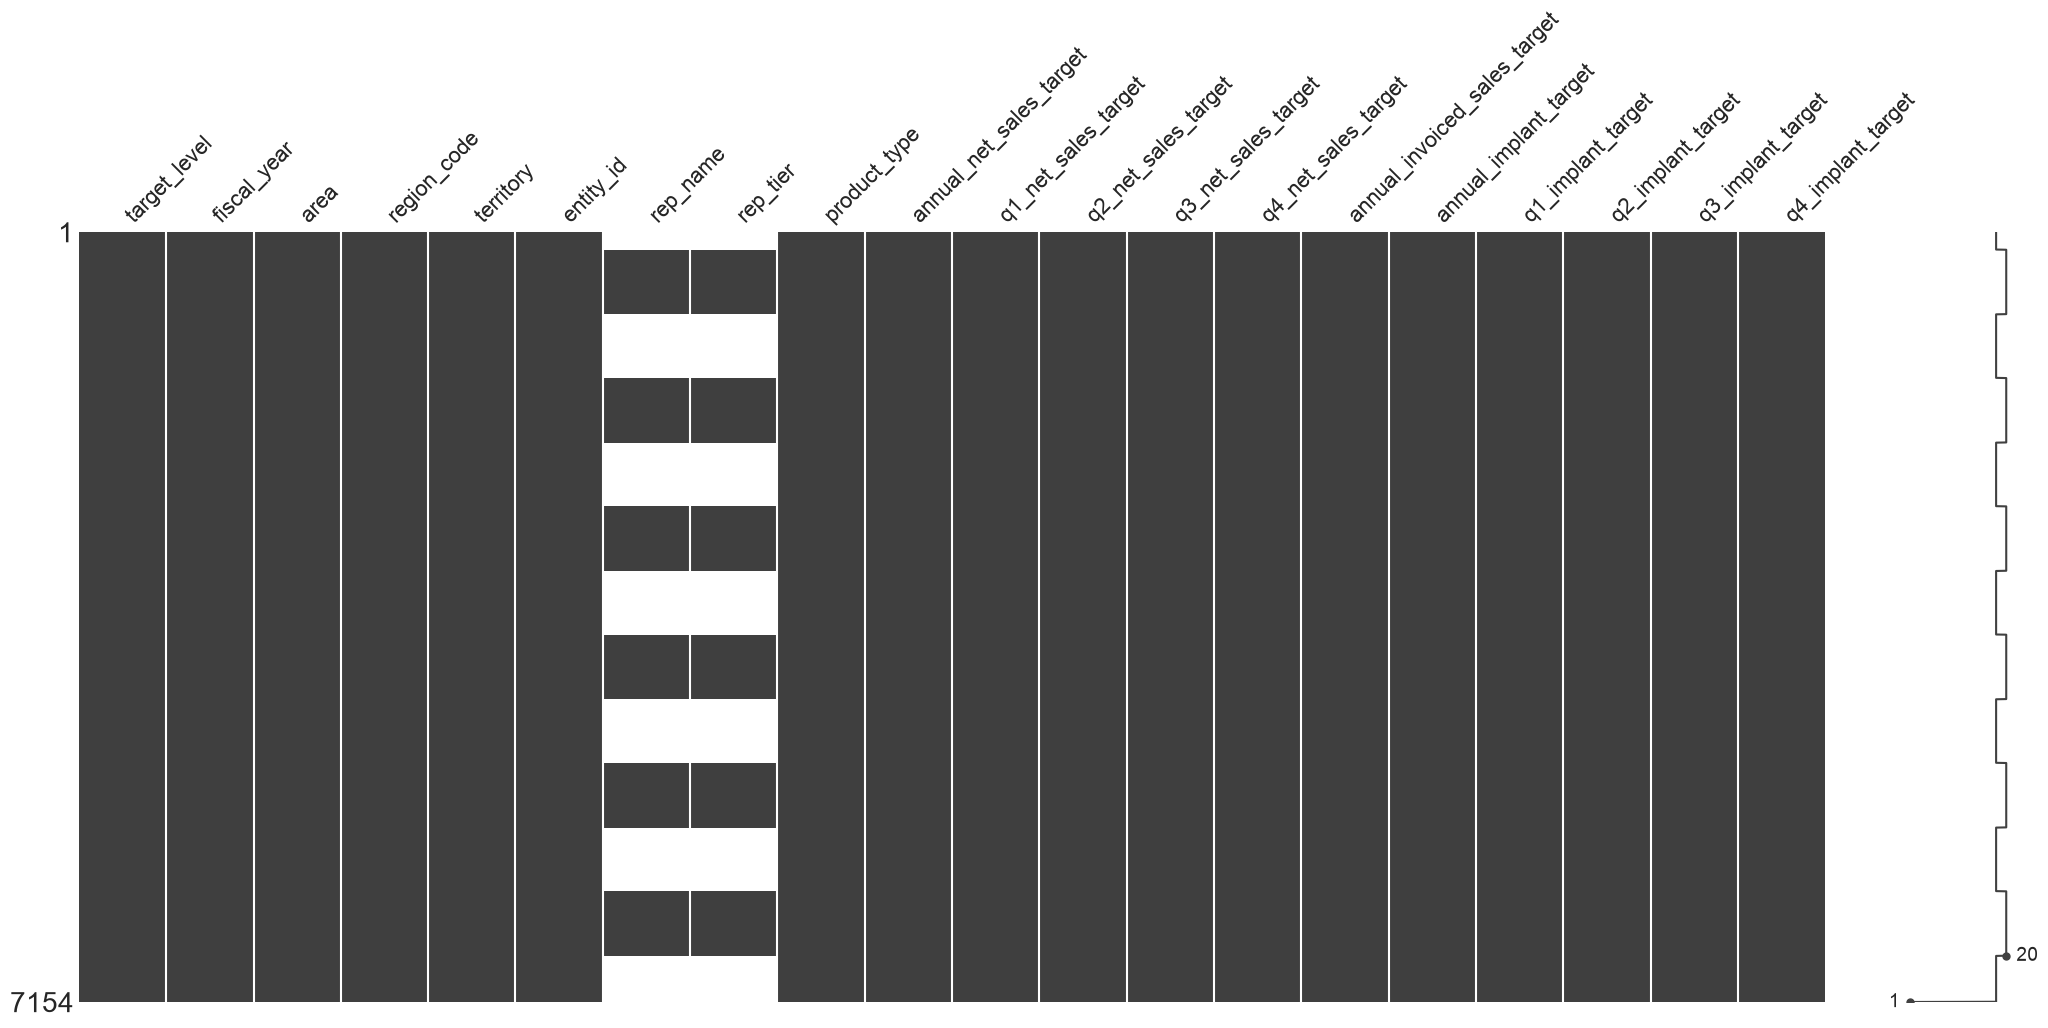

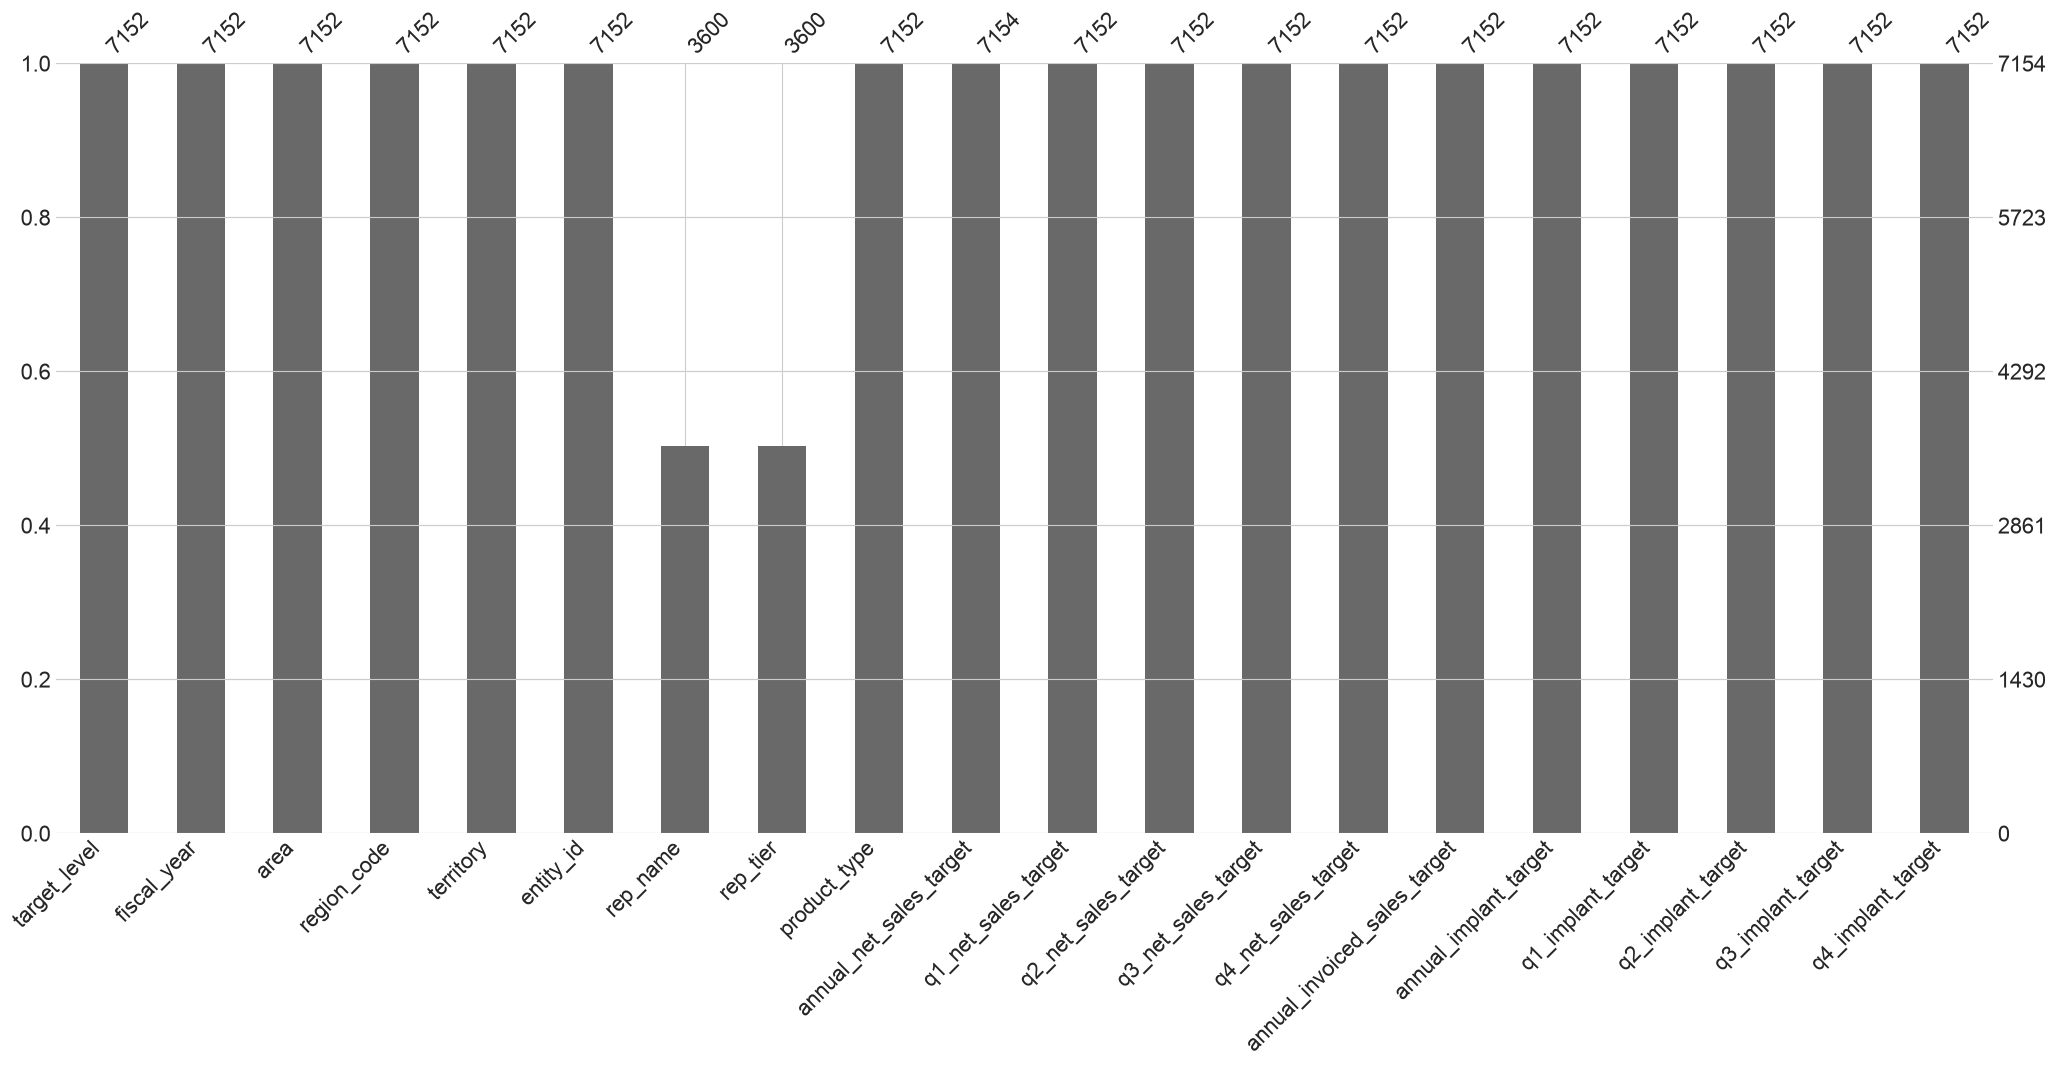

In [10]:
msno.matrix(targets_data)
plt.show()
msno.bar(targets_data)
plt.show()

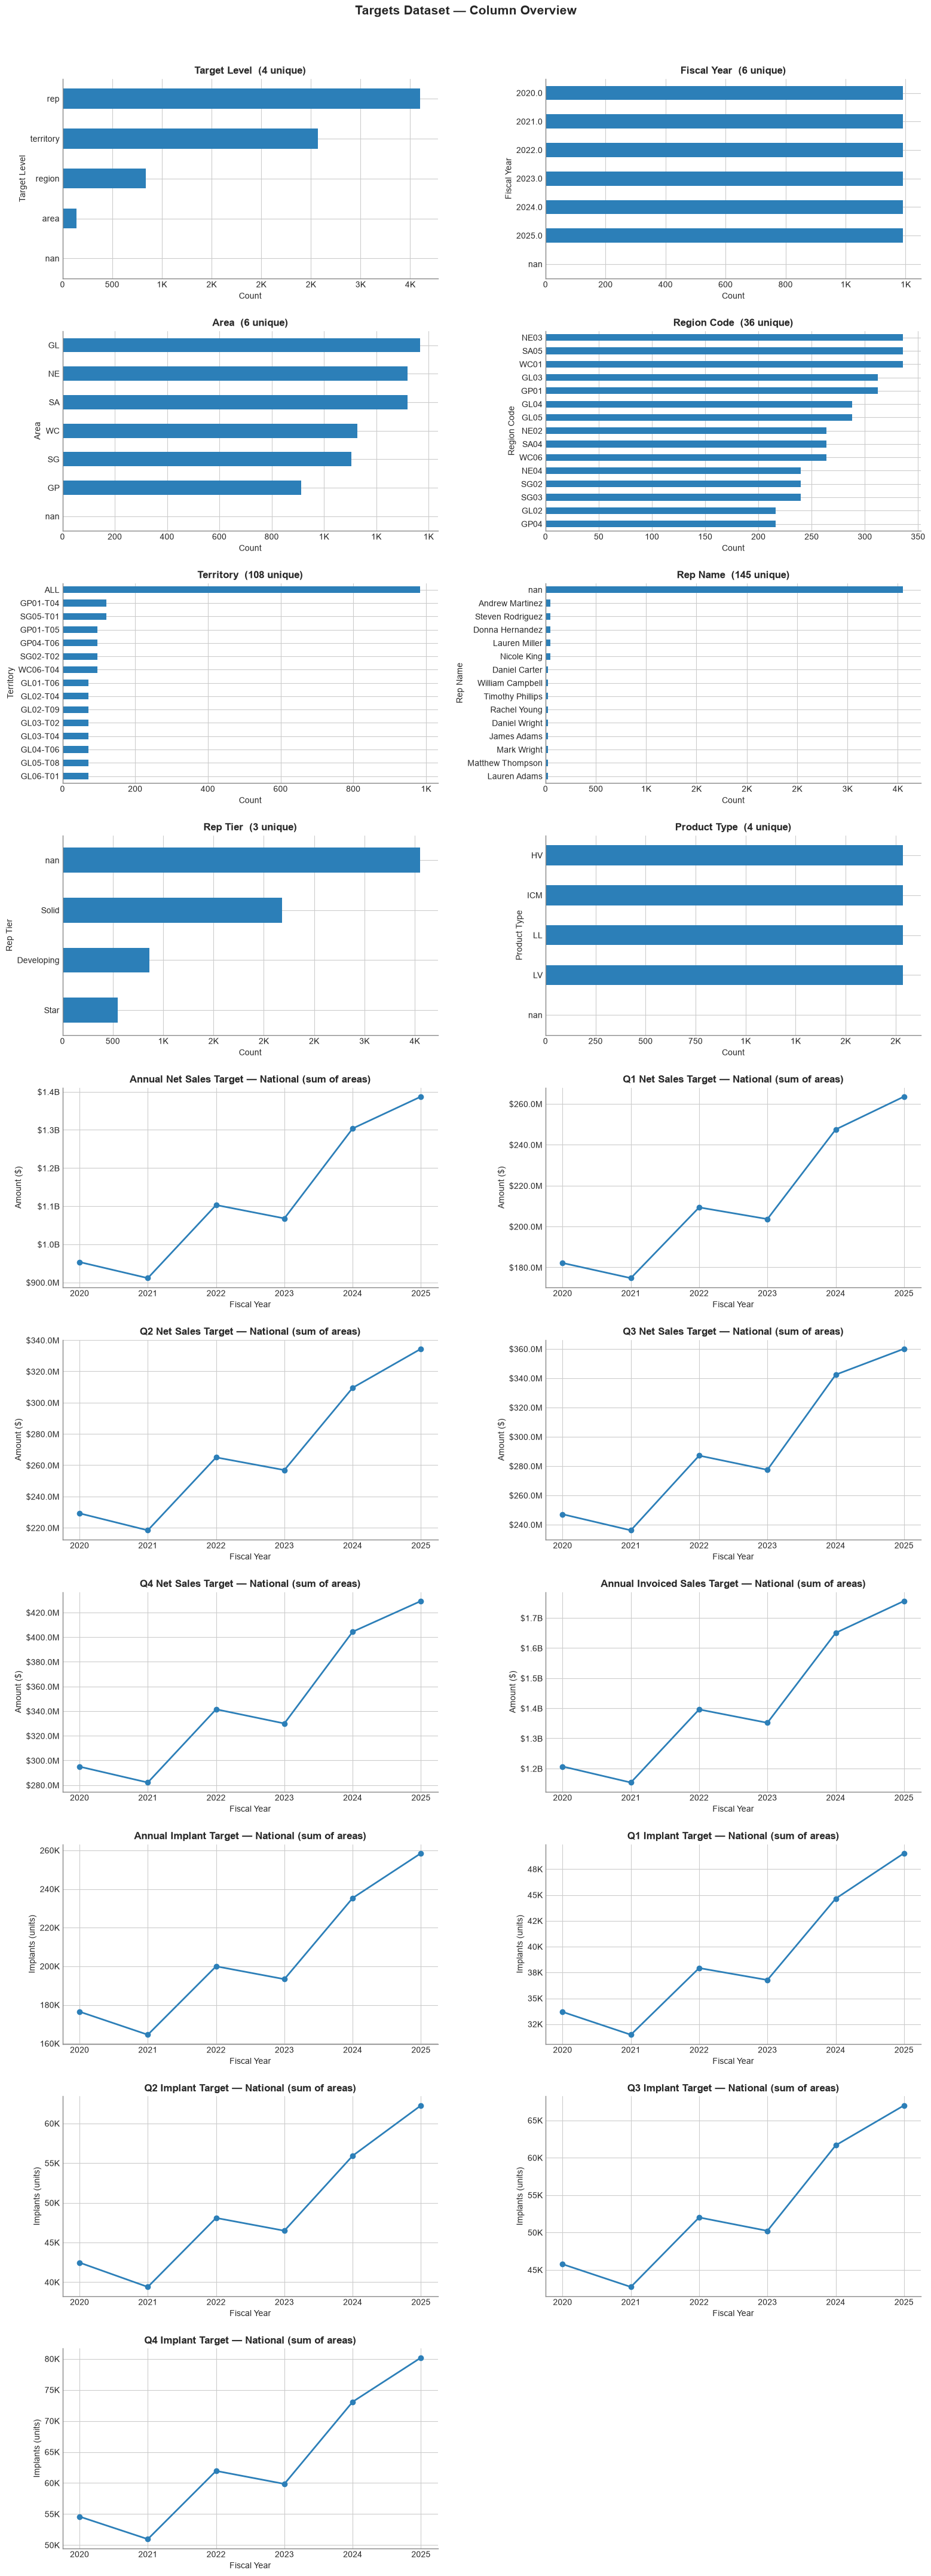

In [11]:
timeseries = ['annual_net_sales_target', 'q1_net_sales_target', 'q2_net_sales_target',
            'q3_net_sales_target', 'q4_net_sales_target', 'annual_invoiced_sales_target',
            'annual_implant_target', 'q1_implant_target', 'q2_implant_target',
            'q3_implant_target', 'q4_implant_target']
money_cols = set(timeseries) - {'annual_implant_target', 'q1_implant_target',
                                'q2_implant_target', 'q3_implant_target', 'q4_implant_target'}
skip = ['entity_id']
cols = [c for c in targets_data.columns if c not in skip]

# area-level only, so years aren't multi-counted across rep/territory/region/area
area_df = targets_data[targets_data['target_level'] == 'area'].copy()
year = pd.to_numeric(area_df['fiscal_year'], errors='coerce')

ncols = 2 
nrows = (len(cols) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4.3 * nrows))

for ax, col in zip(axes.flat, cols):
    if col in timeseries:
        s = pd.to_numeric(area_df[col], errors='coerce').groupby(year).sum().sort_index()
        s.plot.line(ax=ax, marker='o', color=ACCENT, lw=2, markersize=6)
        is_money = col in money_cols
        ax.set_title(f"{nice(col)} — National (sum of areas)")
        ax.set_xlabel("Fiscal Year")
        ax.set_ylabel("Amount ($)" if is_money else "Implants (units)")
        ax.yaxis.set_major_formatter(SI_MONEY if is_money else SI)
        ax.set_xticks(s.index)
    else:
        vc = targets_data[col].value_counts(dropna=False).head(15)
        vc.iloc[::-1].plot.barh(ax=ax, color=ACCENT)
        ax.set_title(f"{nice(col)}  ({targets_data[col].nunique()} unique)")
        ax.set_xlabel("Count")
        ax.set_ylabel(nice(col))          # <-- fixes raw column name on y-axis
        ax.xaxis.set_major_formatter(SI)

for ax in axes.flat[len(cols):]:
    ax.axis('off')

fig.suptitle("Targets Dataset — Column Overview", fontsize=15, fontweight="bold", y=1.005)
plt.tight_layout(pad=2.2)
plt.show()


## Deliverable 1 - Executive View: Implants

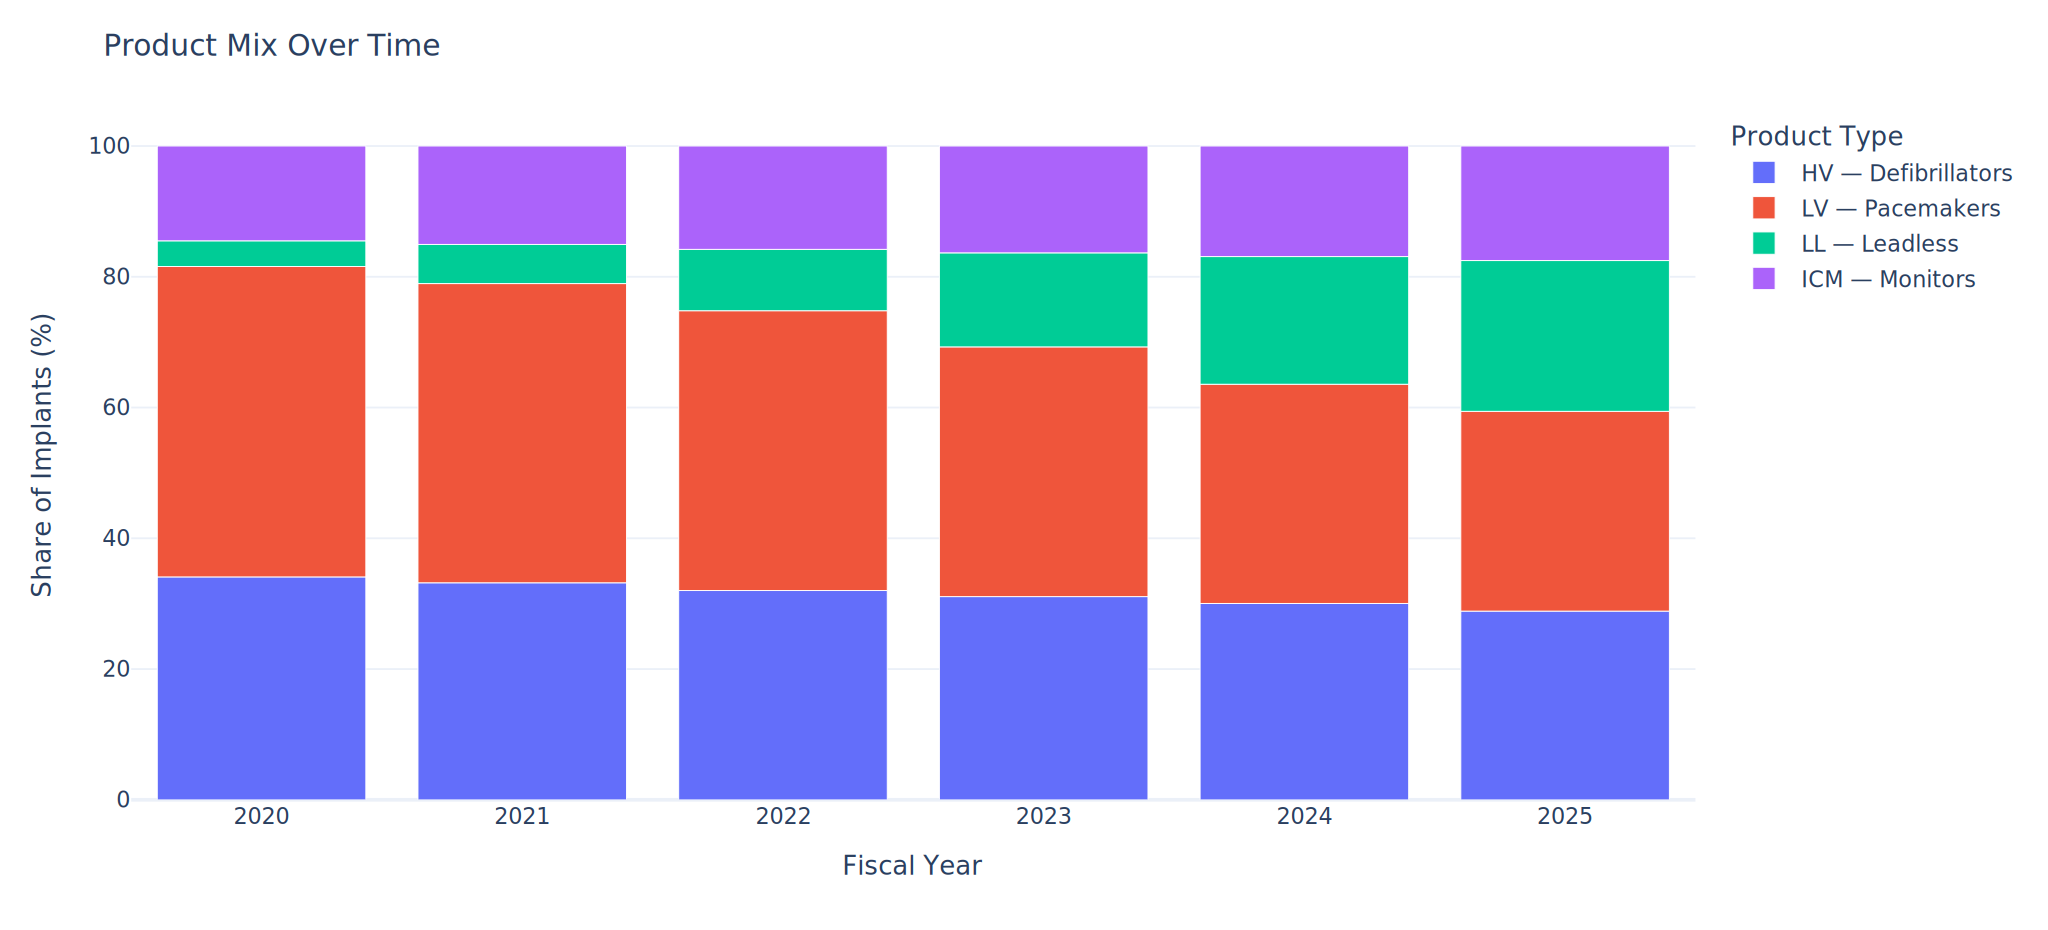

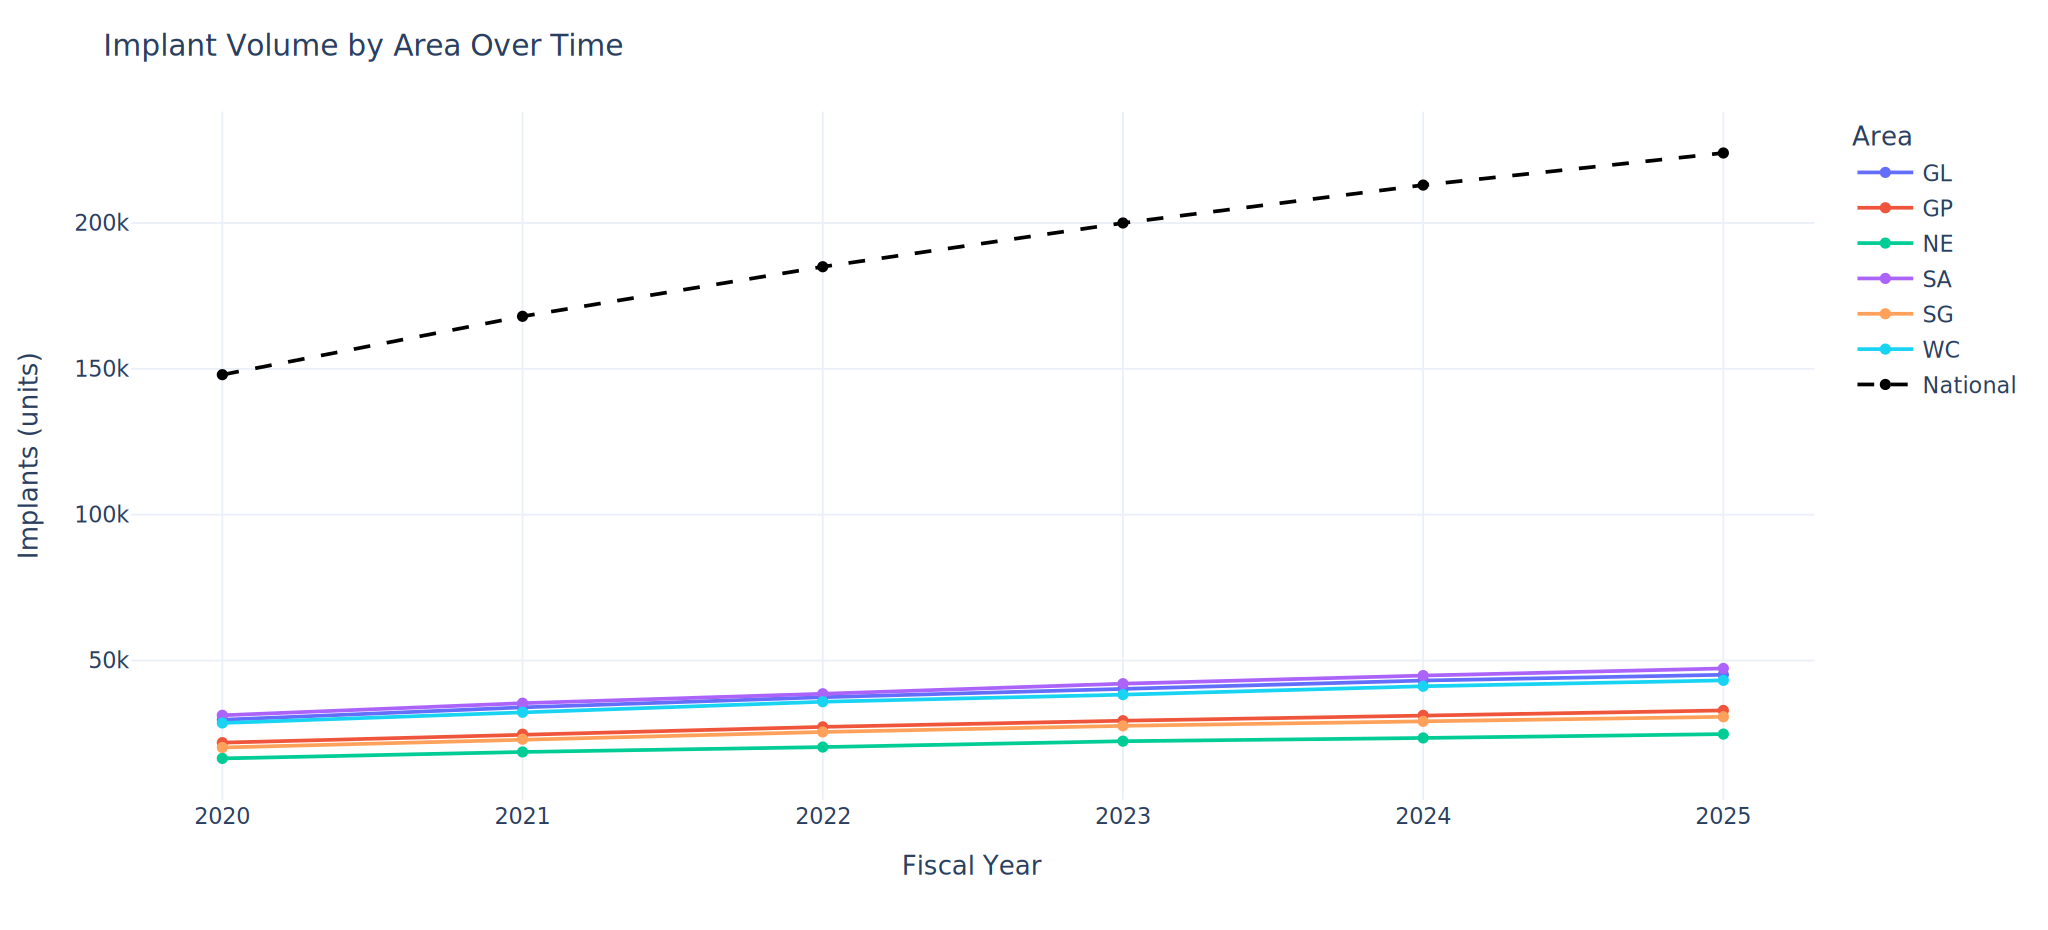

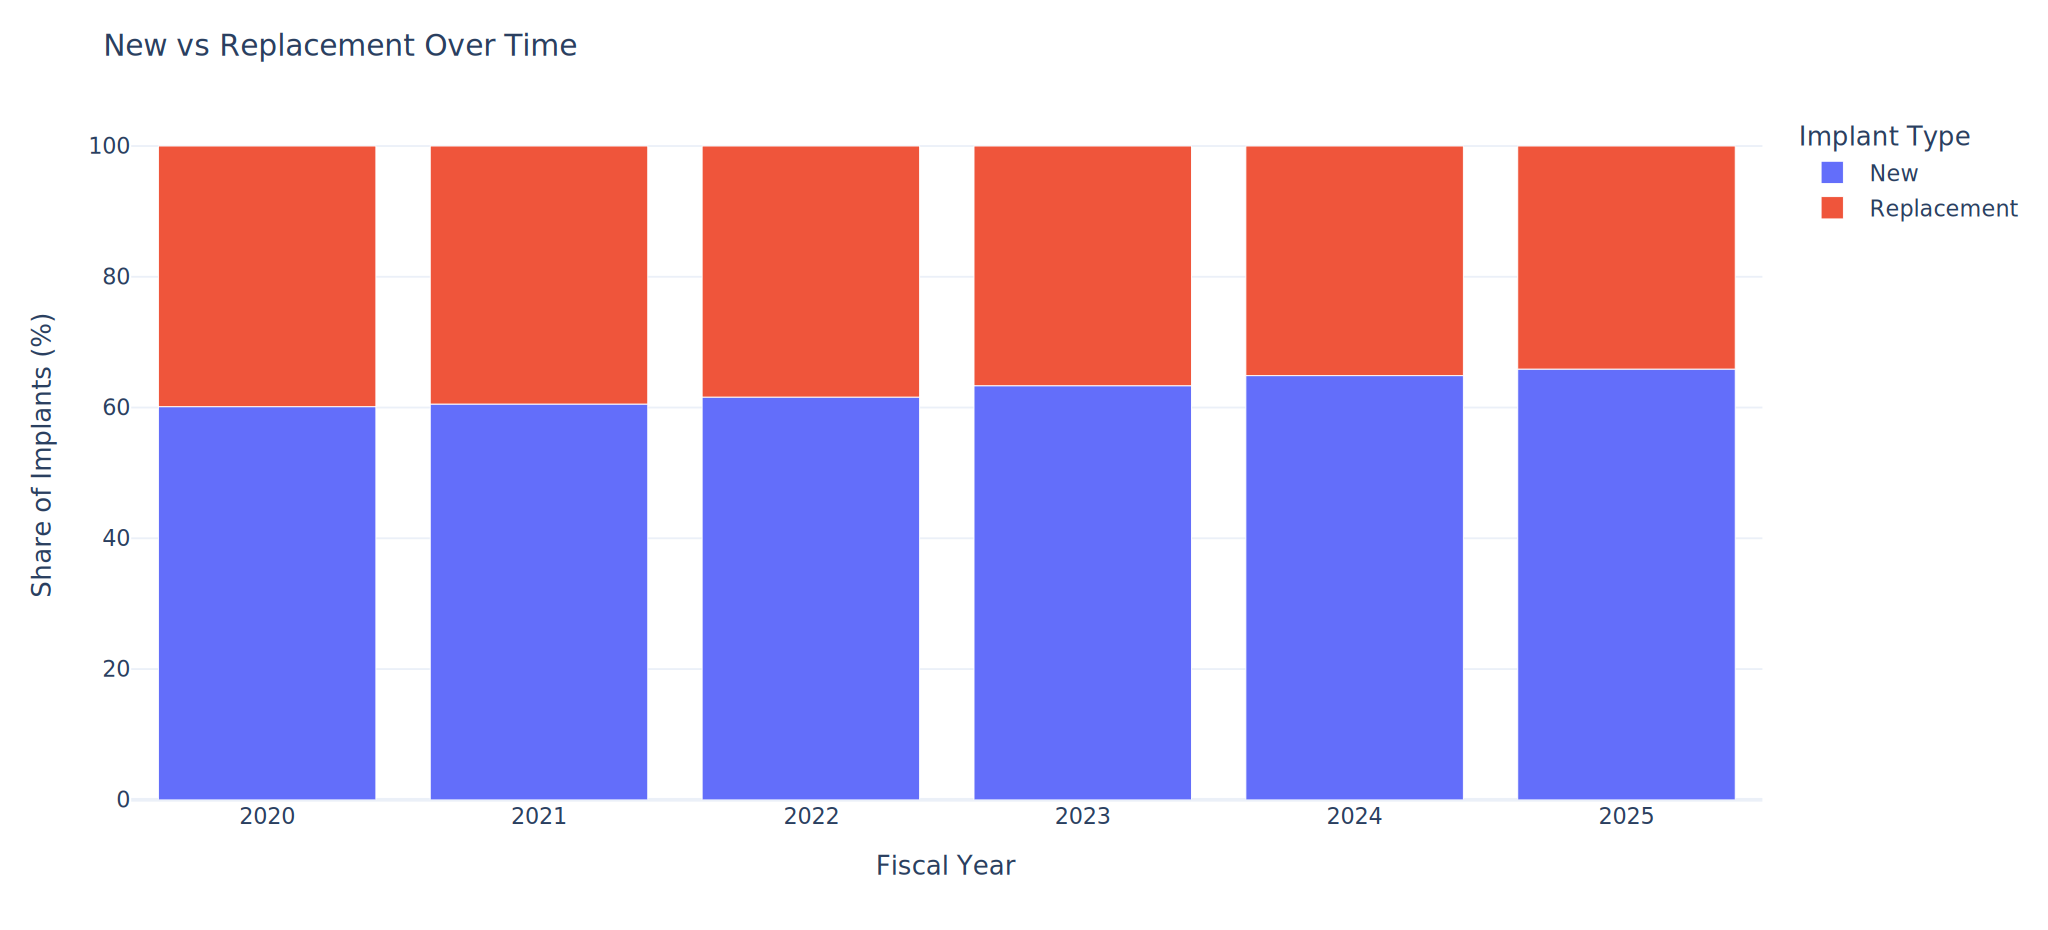

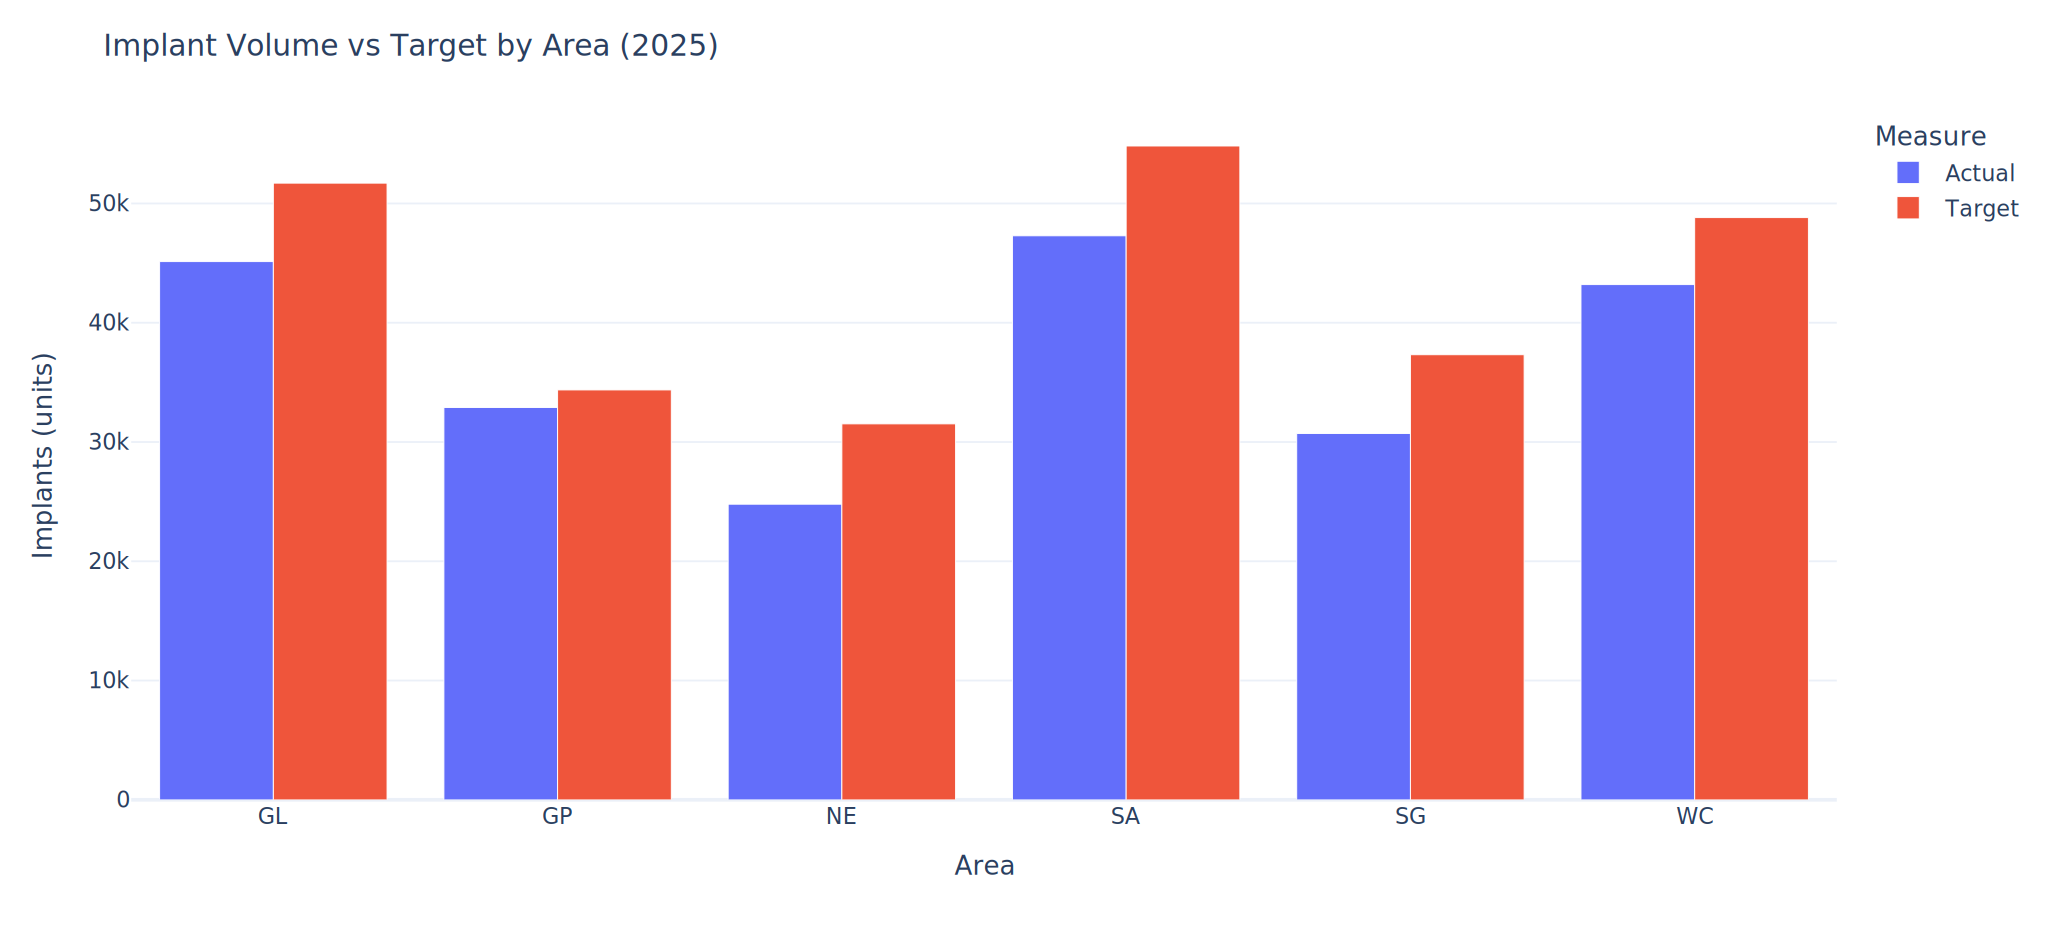

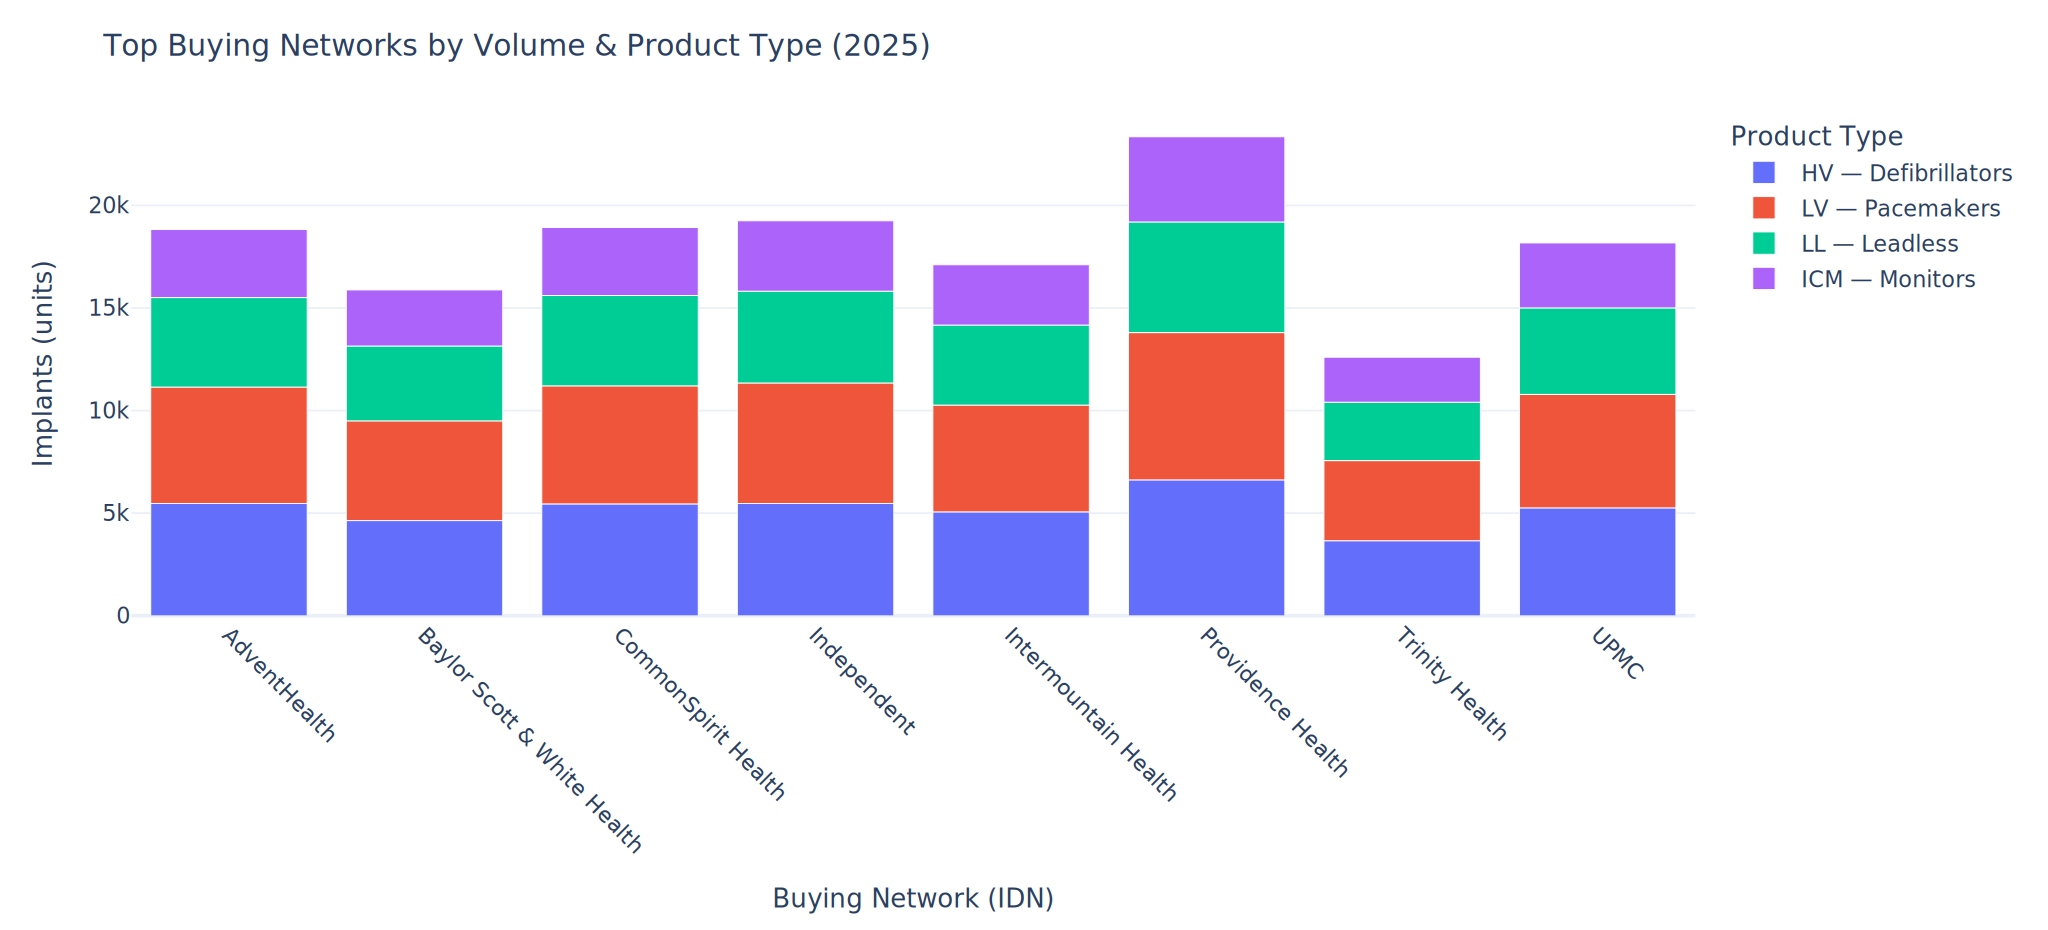

In [12]:
imp = pd.read_csv("data/crm_implants.csv",
                  usecols=["fiscal_year", "area", "product_type",
                           "implant_type", "idn_name", "serial_number"])
imp["fiscal_year"] = imp["fiscal_year"].astype(int)

LATEST = imp["fiscal_year"].max()
PREV = LATEST - 1

PT_LABELS = {"HV": "HV \u2014 Defibrillators", "LV": "LV \u2014 Pacemakers",
             "LL": "LL \u2014 Leadless", "ICM": "ICM \u2014 Monitors"}
PT_ORDER = [PT_LABELS[c] for c in ["HV", "LV", "LL", "ICM"]]
ORDER = {"product_type": PT_ORDER}

TEMPLATE = "plotly_white"

def style(fig, title, xtitle, ytitle, legend=None):
    fig.update_layout(
        template=TEMPLATE, title=title, title_font=dict(size=16),
        xaxis_title=xtitle, yaxis_title=ytitle,
        paper_bgcolor="white", plot_bgcolor="white",
        legend_title_text=legend, margin=dict(t=60, l=70, r=30, b=70),
    )
    return fig

# 1) Product mix over time (100%-stacked)
mix = imp.groupby(["fiscal_year", "product_type"]).size().reset_index(name="volume")
mix["product_type"] = mix["product_type"].map(PT_LABELS)
fig2 = px.bar(mix, x="fiscal_year", y="volume", color="product_type", category_orders=ORDER)
fig2.update_layout(barnorm="percent")
style(fig2, "Product Mix Over Time", "Fiscal Year", "Share of Implants (%)", "Product Type")
fig2.show()

# 2) Implant volume by area over time
area_year = imp.groupby(["fiscal_year", "area"]).size().reset_index(name="volume")
fig3 = px.line(area_year, x="fiscal_year", y="volume", color="area", markers=True)
nat = imp.groupby("fiscal_year").size().reset_index(name="volume")
fig3.add_scatter(x=nat.fiscal_year, y=nat.volume, mode="lines+markers",
                 name="National", line=dict(dash="dash", color="black"))
style(fig3, "Implant Volume by Area Over Time", "Fiscal Year", "Implants (units)", "Area")
fig3.show()

# 3) New vs Replacement over time (100%-stacked)
nr = imp.groupby(["fiscal_year", "implant_type"]).size().reset_index(name="volume")
fig4 = px.bar(nr, x="fiscal_year", y="volume", color="implant_type")
fig4.update_layout(barnorm="percent")
style(fig4, "New vs Replacement Over Time", "Fiscal Year", "Share of Implants (%)", "Implant Type")
fig4.show()

# 4) Volume vs target (attainment) by area, latest year
tgt = pd.read_csv("data/targets_data.csv",
                  usecols=["target_level", "fiscal_year", "area",
                           "product_type", "annual_implant_target"])
tgt = tgt[(tgt.target_level == "area") & (tgt.fiscal_year == LATEST)]
tgt_area = tgt.groupby("area")["annual_implant_target"].sum()
act_area = imp[imp.fiscal_year == LATEST].groupby("area").size()
att = (pd.DataFrame({"Actual": act_area, "Target": tgt_area})
       .reset_index().melt(id_vars="area", var_name="measure", value_name="implants"))
fig5 = px.bar(att, x="area", y="implants", color="measure", barmode="group")
style(fig5, f"Implant Volume vs Target by Area ({LATEST})", "Area", "Implants (units)", "Measure")
fig5.show()

# 5) Top buying networks (IDNs) by volume & product type, latest year
last = imp[imp.fiscal_year == LATEST]
top_idn = last["idn_name"].value_counts().head(8).index
d6 = (last[last.idn_name.isin(top_idn)]
      .groupby(["idn_name", "product_type"]).size().reset_index(name="volume"))
d6["product_type"] = d6["product_type"].map(PT_LABELS)
fig6 = px.bar(d6, x="idn_name", y="volume", color="product_type", category_orders=ORDER)
style(fig6, f"Top Buying Networks by Volume & Product Type ({LATEST})",
      "Buying Network (IDN)", "Implants (units)", "Product Type")
fig6.update_xaxes(tickangle=45)
fig6.show()


## Deliverable 2 - Executive View: Sales

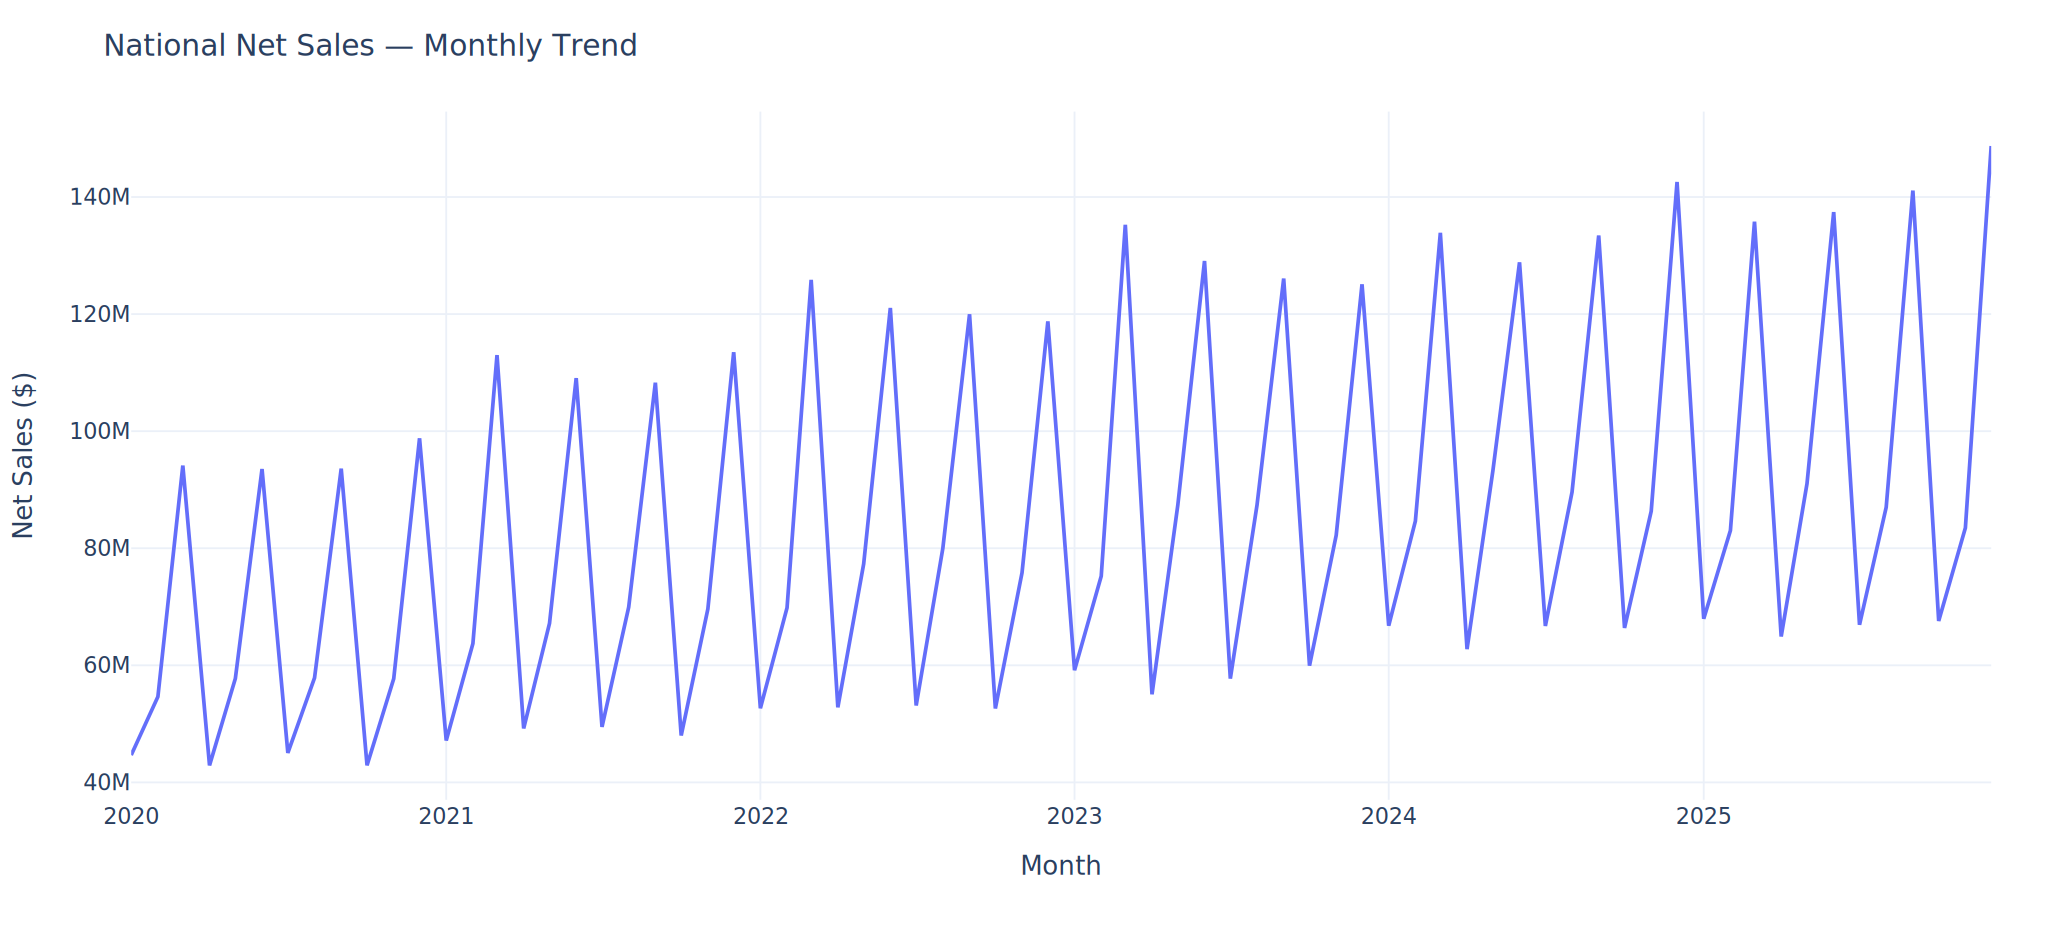

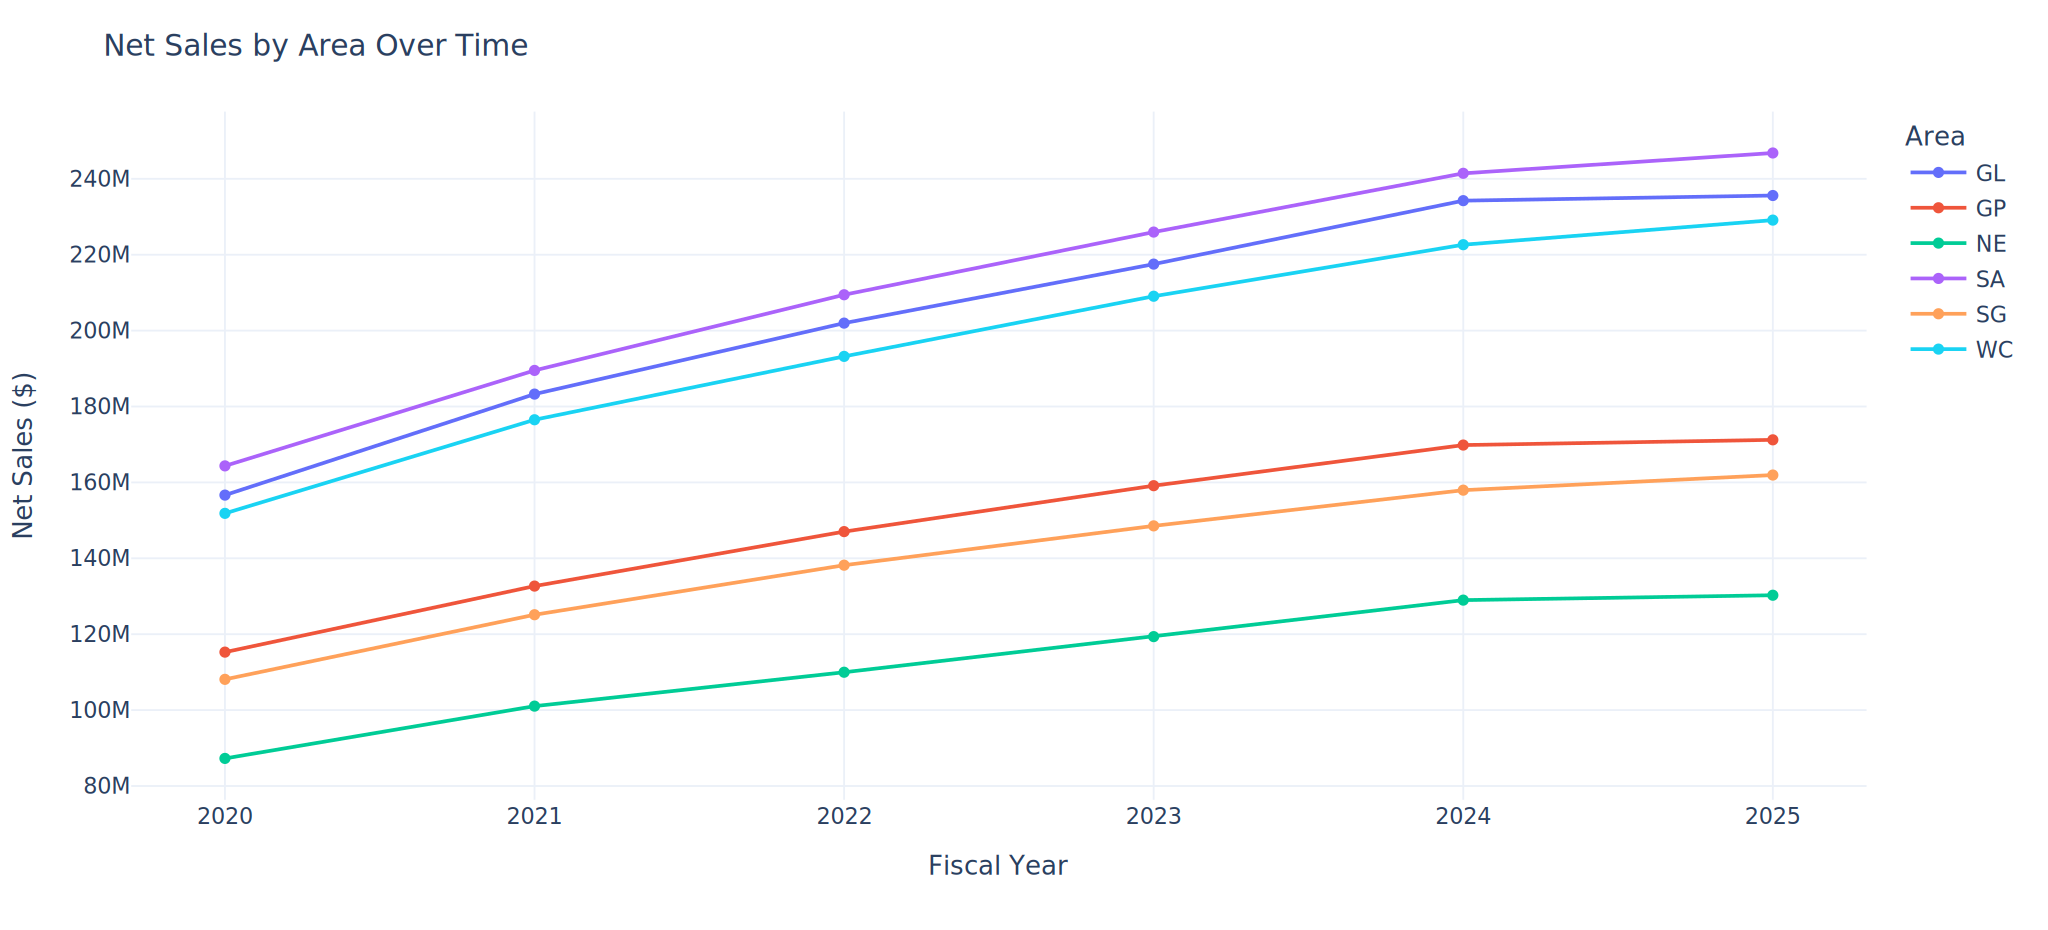

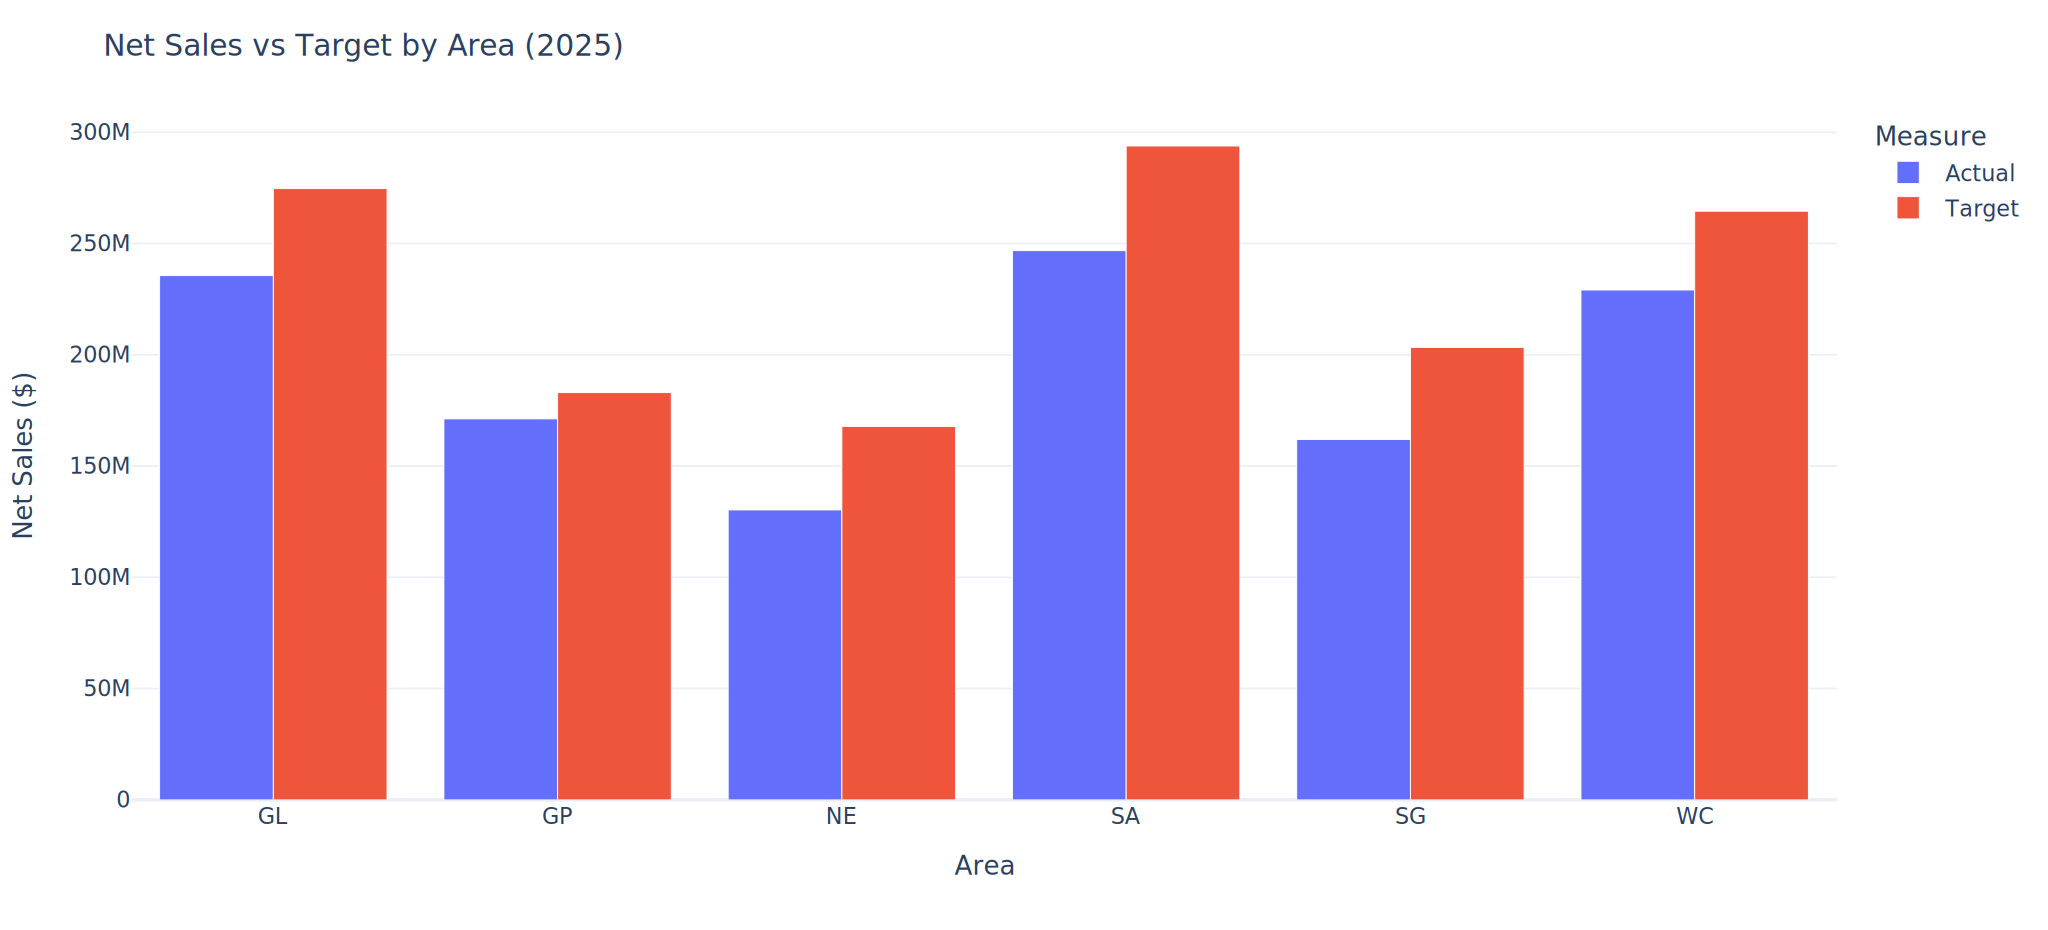

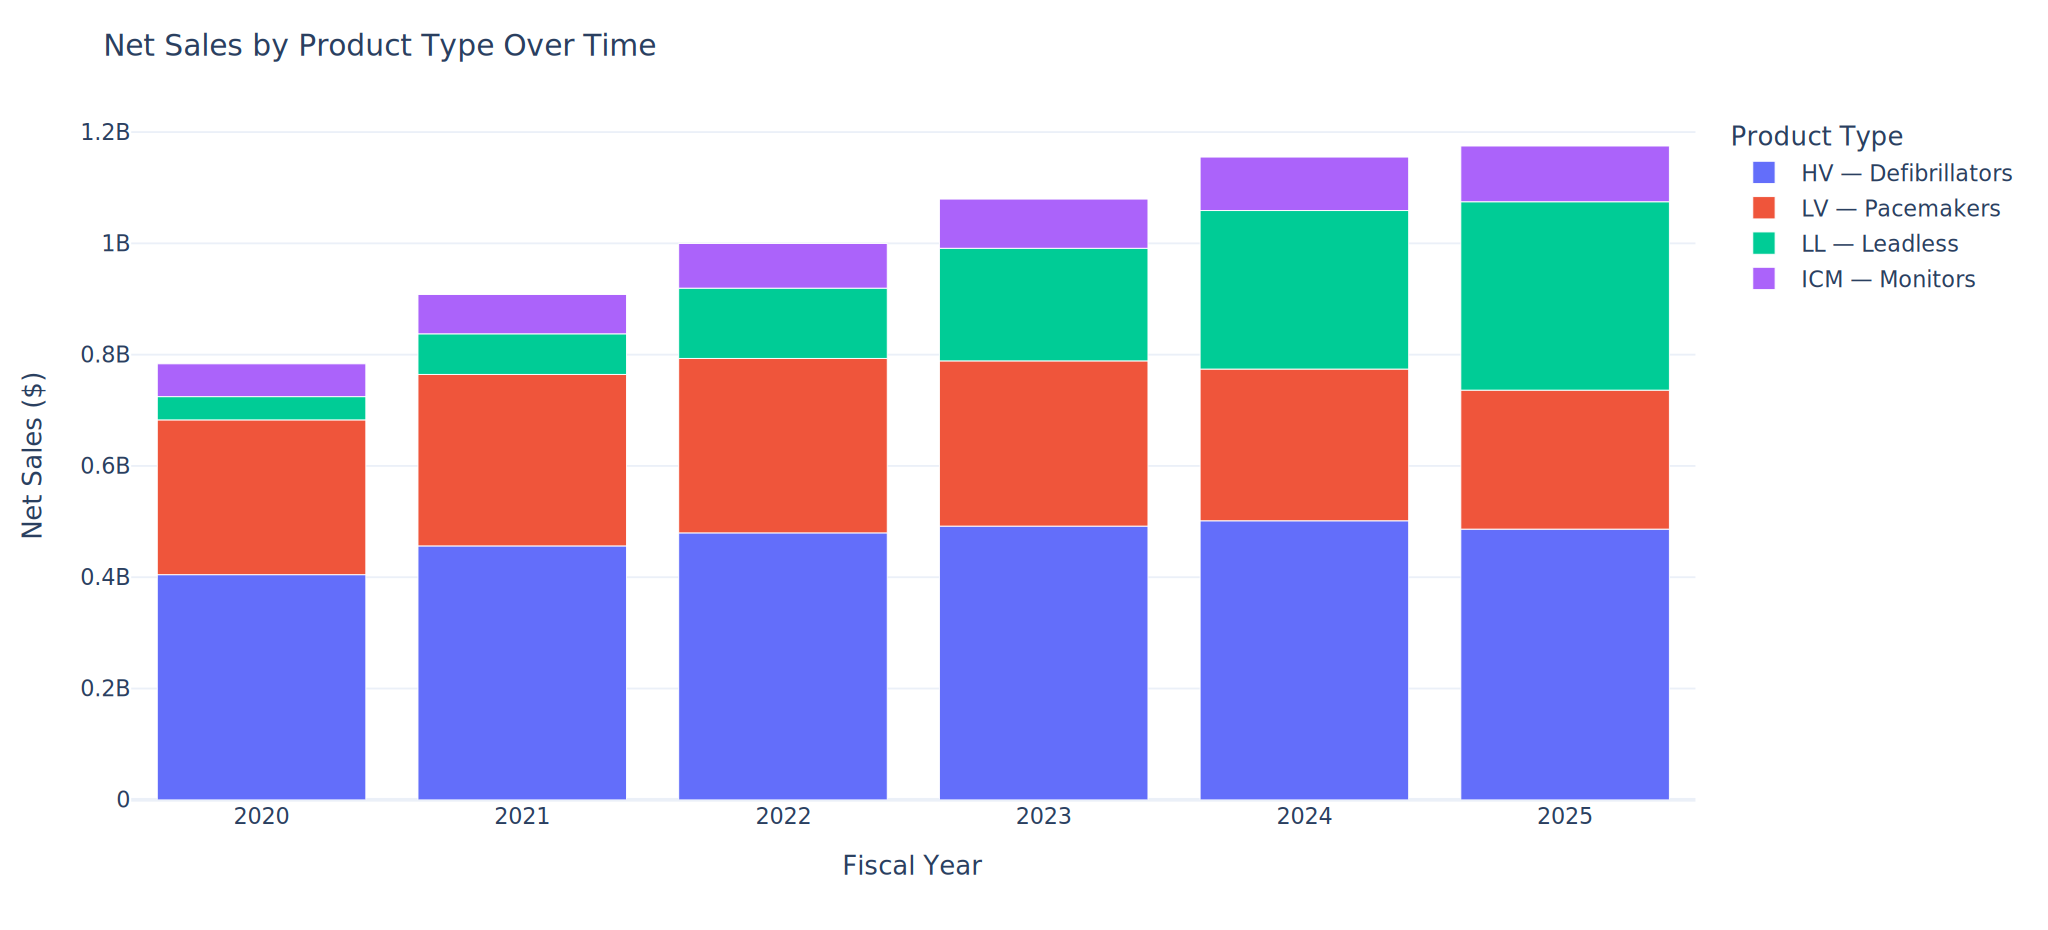

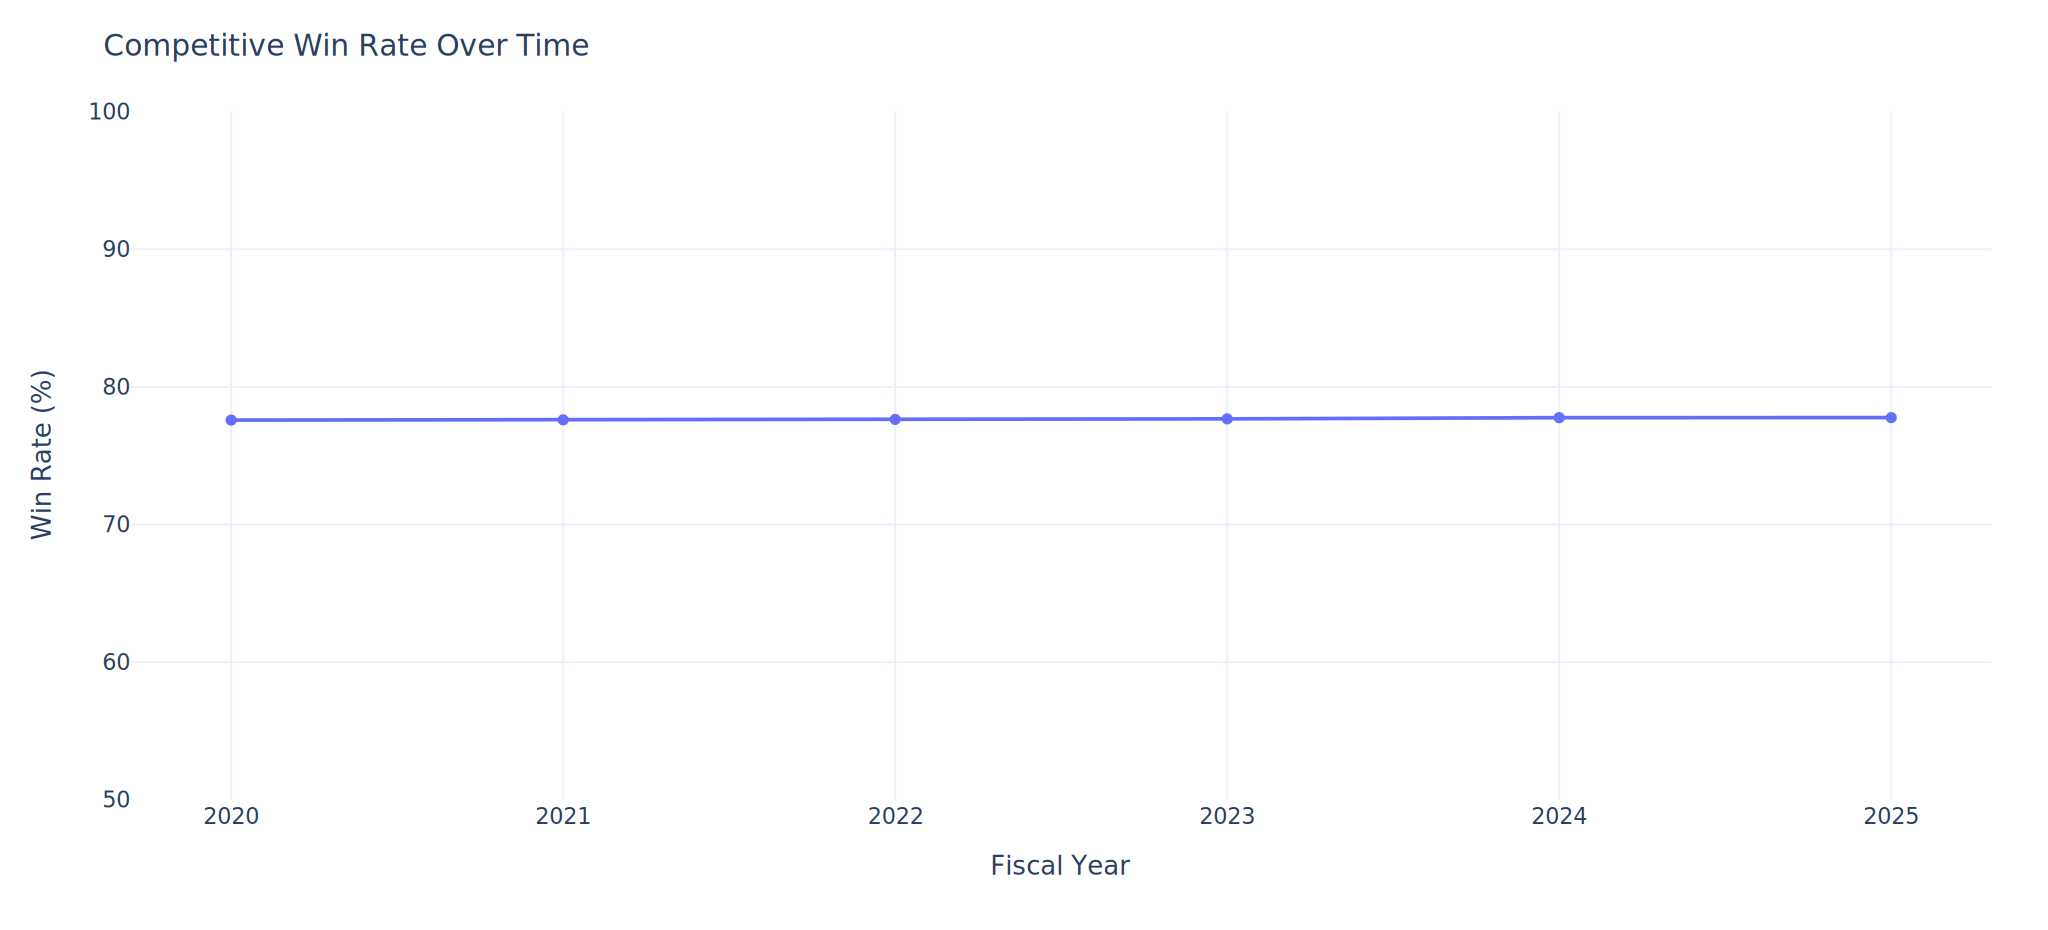

In [13]:
sal = pd.read_csv("data/crm_sales.csv",
                usecols=["fiscal_year", "sales_date", "area", "product_type",
                            "net_sales", "competitive_win_flag"])
sal["net_sales"] = pd.to_numeric(sal["net_sales"], errors="coerce")
sal["fiscal_year"] = sal["fiscal_year"].astype(int)
sal["month"] = pd.to_datetime(sal["sales_date"]).dt.to_period("M").dt.to_timestamp()
sal["is_win"] = sal["competitive_win_flag"].astype(str).eq("True")

LATEST = sal["fiscal_year"].max()
PREV = LATEST - 1

PT_LABELS = {"HV": "HV \u2014 Defibrillators", "LV": "LV \u2014 Pacemakers",
            "LL": "LL \u2014 Leadless", "ICM": "ICM \u2014 Monitors"}
PT_ORDER = {"product_type": [PT_LABELS[c] for c in ["HV", "LV", "LL", "ICM"]]}
TEMPLATE = "plotly_white"

def style(fig, title, xtitle, ytitle, legend=None):
    fig.update_layout(template=TEMPLATE, title=title, title_font=dict(size=16),
                    xaxis_title=xtitle, yaxis_title=ytitle,
                    paper_bgcolor="white", plot_bgcolor="white",
                    legend_title_text=legend, margin=dict(t=60, l=70, r=30, b=70))
    return fig


# 2) Monthly net sales trend (CENTERPIECE — seasonality)
monthly = sal.groupby("month")["net_sales"].sum().reset_index()
monthly["month"] = monthly["month"].dt.strftime("%Y-%m-%d")  # kaleido can't serialize Timestamps
fig2 = px.line(monthly, x="month", y="net_sales", markers=False)
fig2.update_traces(line=dict(width=2))
style(fig2, "National Net Sales \u2014 Monthly Trend", "Month", "Net Sales ($)")
fig2.show()

# 3) Net sales by area over time
area_year = sal.groupby(["fiscal_year", "area"])["net_sales"].sum().reset_index()
fig3 = px.line(area_year, x="fiscal_year", y="net_sales", color="area", markers=True)
style(fig3, "Net Sales by Area Over Time", "Fiscal Year", "Net Sales ($)", "Area")
fig3.show()

# 4) Net sales vs target (attainment) by area, latest year
tgt = pd.read_csv("data/targets_data.csv",
                usecols=["target_level", "fiscal_year", "area", "annual_net_sales_target"])
tgt = tgt[(tgt.target_level == "area") & (tgt.fiscal_year == LATEST)]
tgt_area = tgt.groupby("area")["annual_net_sales_target"].sum()
act_area = sal[sal.fiscal_year == LATEST].groupby("area")["net_sales"].sum()
att = (pd.DataFrame({"Actual": act_area, "Target": tgt_area})
        .reset_index().melt(id_vars="area", var_name="measure", value_name="net_sales"))
fig4 = px.bar(att, x="area", y="net_sales", color="measure", barmode="group")
style(fig4, f"Net Sales vs Target by Area ({LATEST})", "Area", "Net Sales ($)", "Measure")
fig4.show()

# 5) Net sales by product type over time (dollar mix)
prod = sal.groupby(["fiscal_year", "product_type"])["net_sales"].sum().reset_index()
prod["product_type"] = prod["product_type"].map(PT_LABELS)
fig5 = px.bar(prod, x="fiscal_year", y="net_sales", color="product_type", category_orders=PT_ORDER)
style(fig5, "Net Sales by Product Type Over Time", "Fiscal Year", "Net Sales ($)", "Product Type")
fig5.show()

# 6) Competitive win rate over time
win = sal.groupby("fiscal_year")["is_win"].mean().mul(100).reset_index(name="win_rate")
fig6 = px.line(win, x="fiscal_year", y="win_rate", markers=True)
fig6.update_traces(line=dict(width=2))
fig6.update_yaxes(range=[50, 100])
style(fig6, "Competitive Win Rate Over Time", "Fiscal Year", "Win Rate (%)")
fig6.show()

## Deliverable 3 - 12-Month Forecast

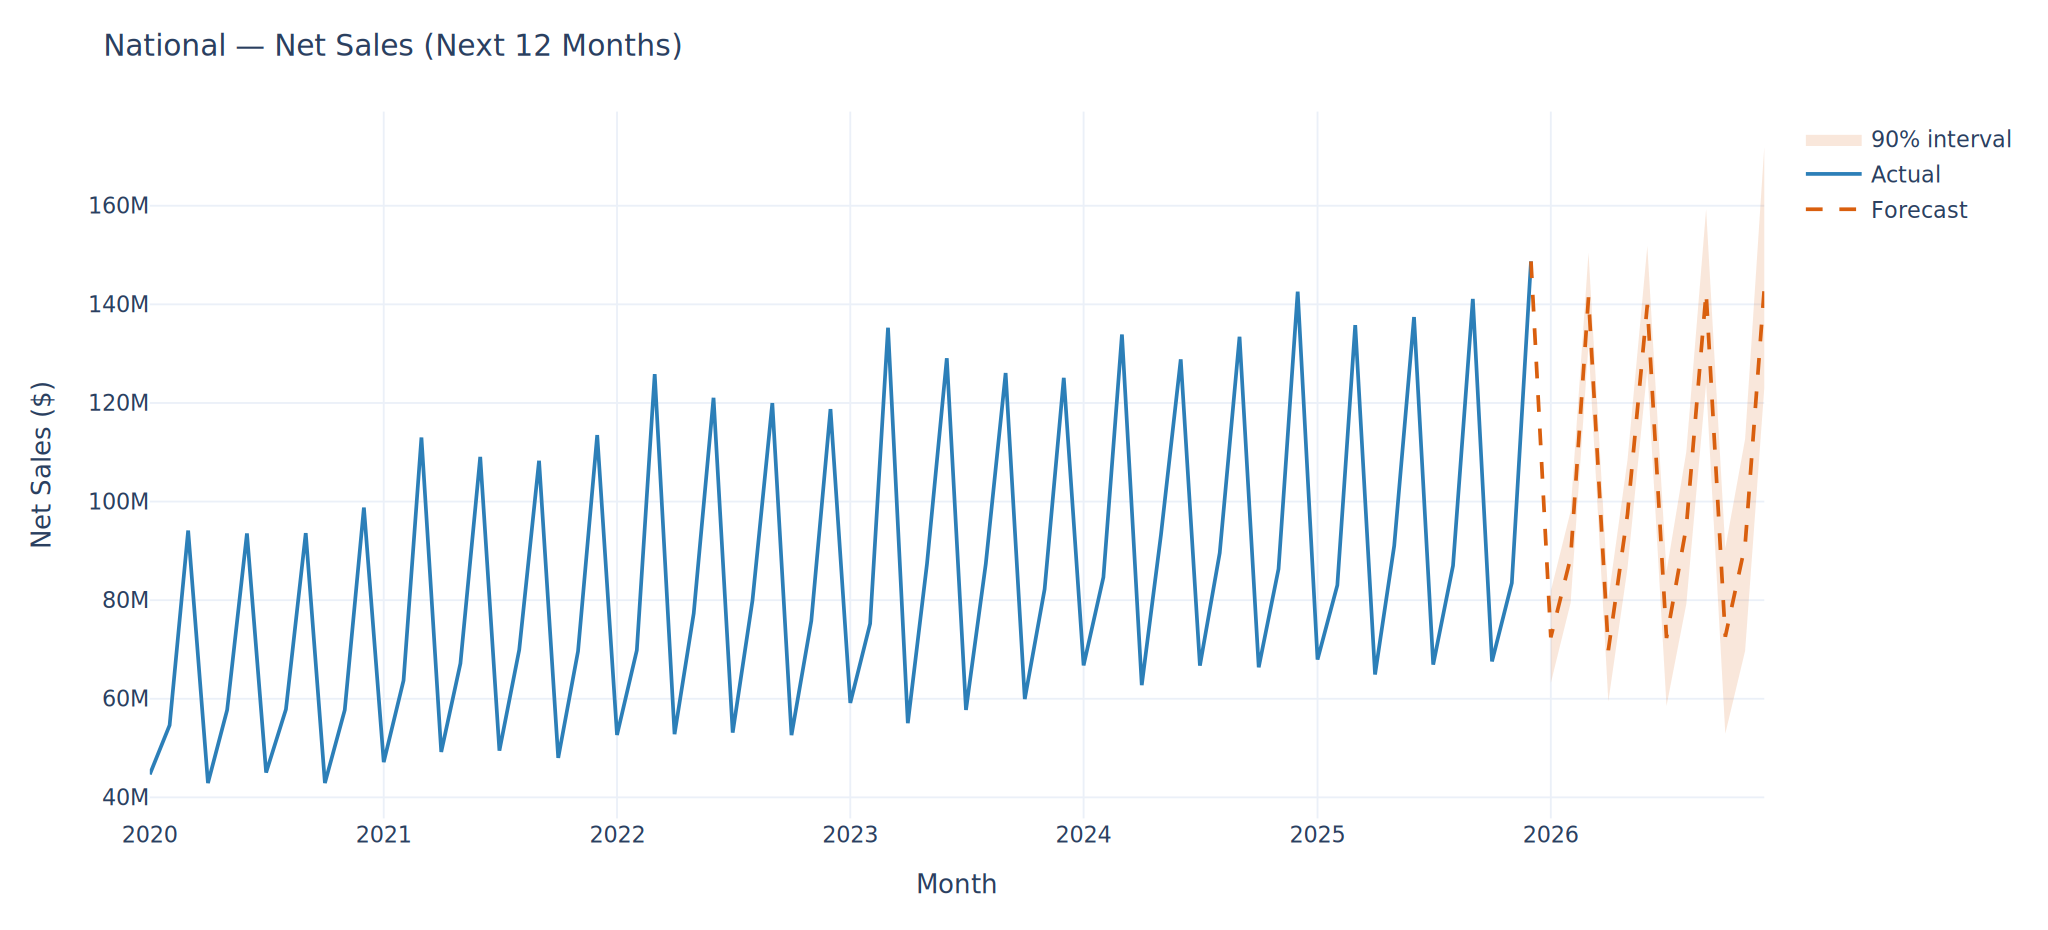

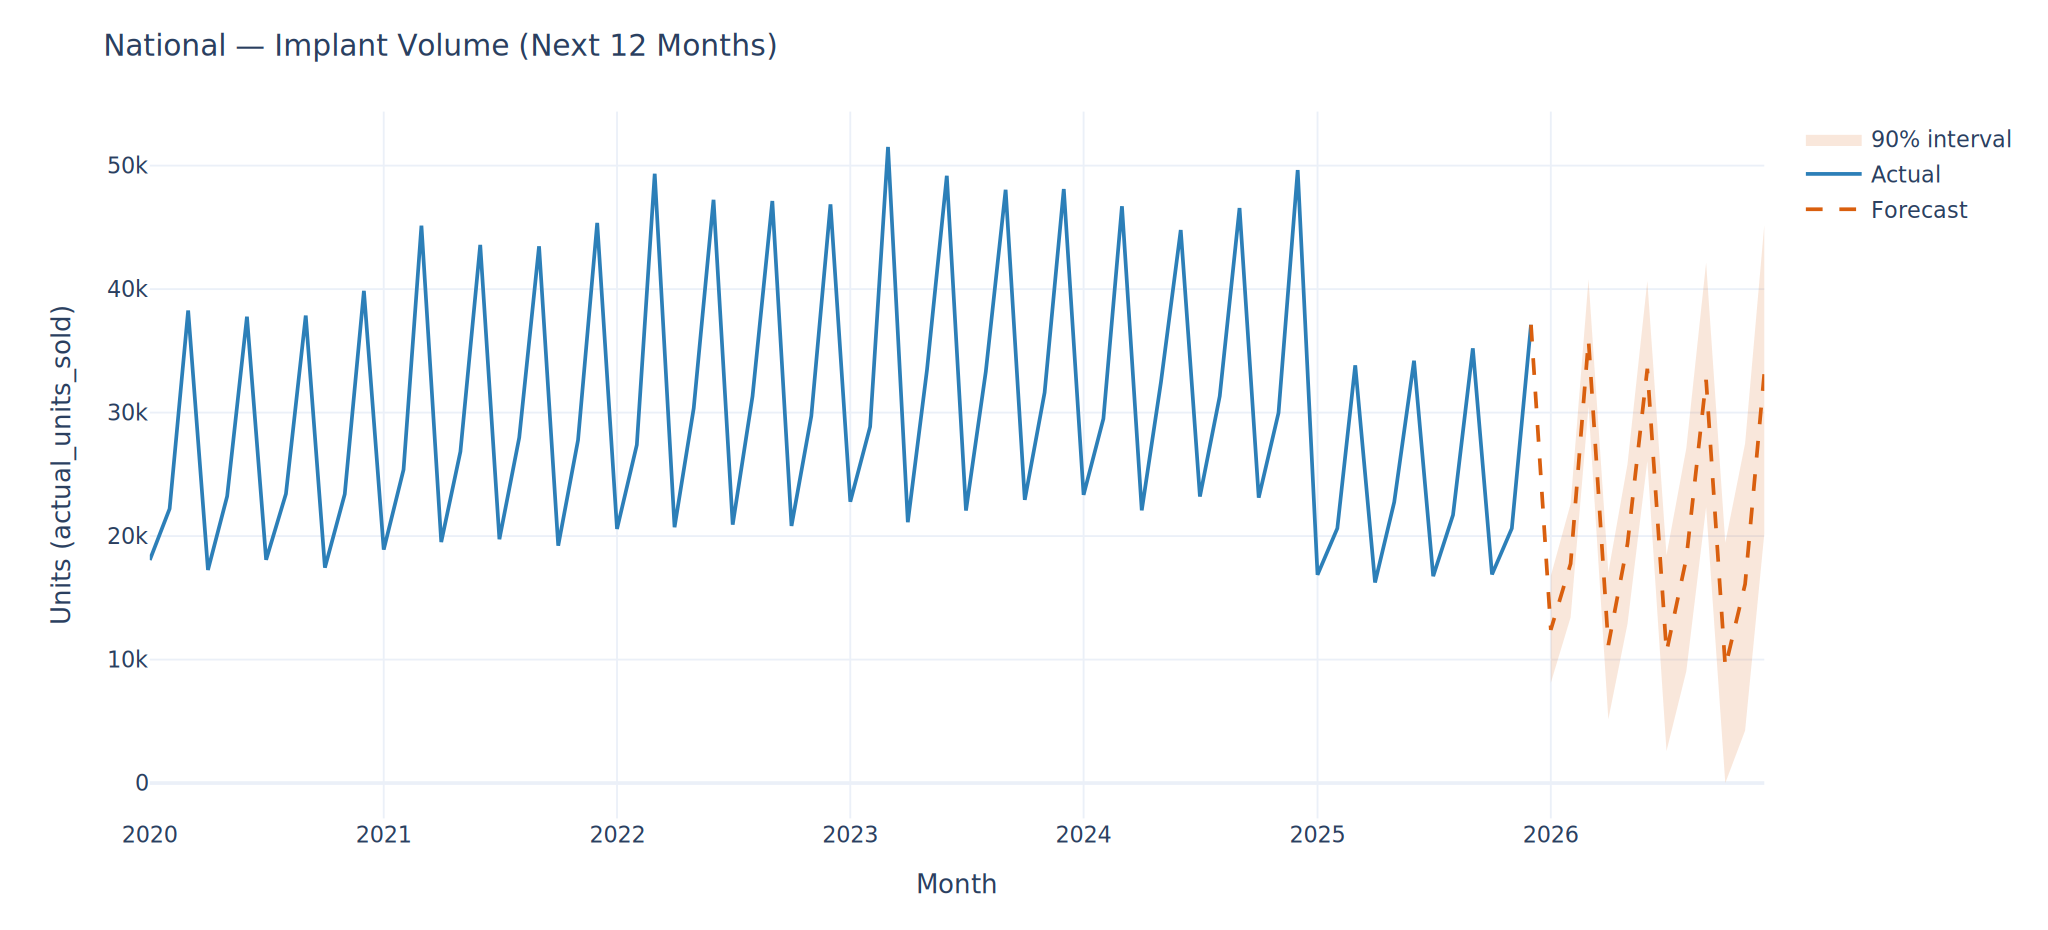

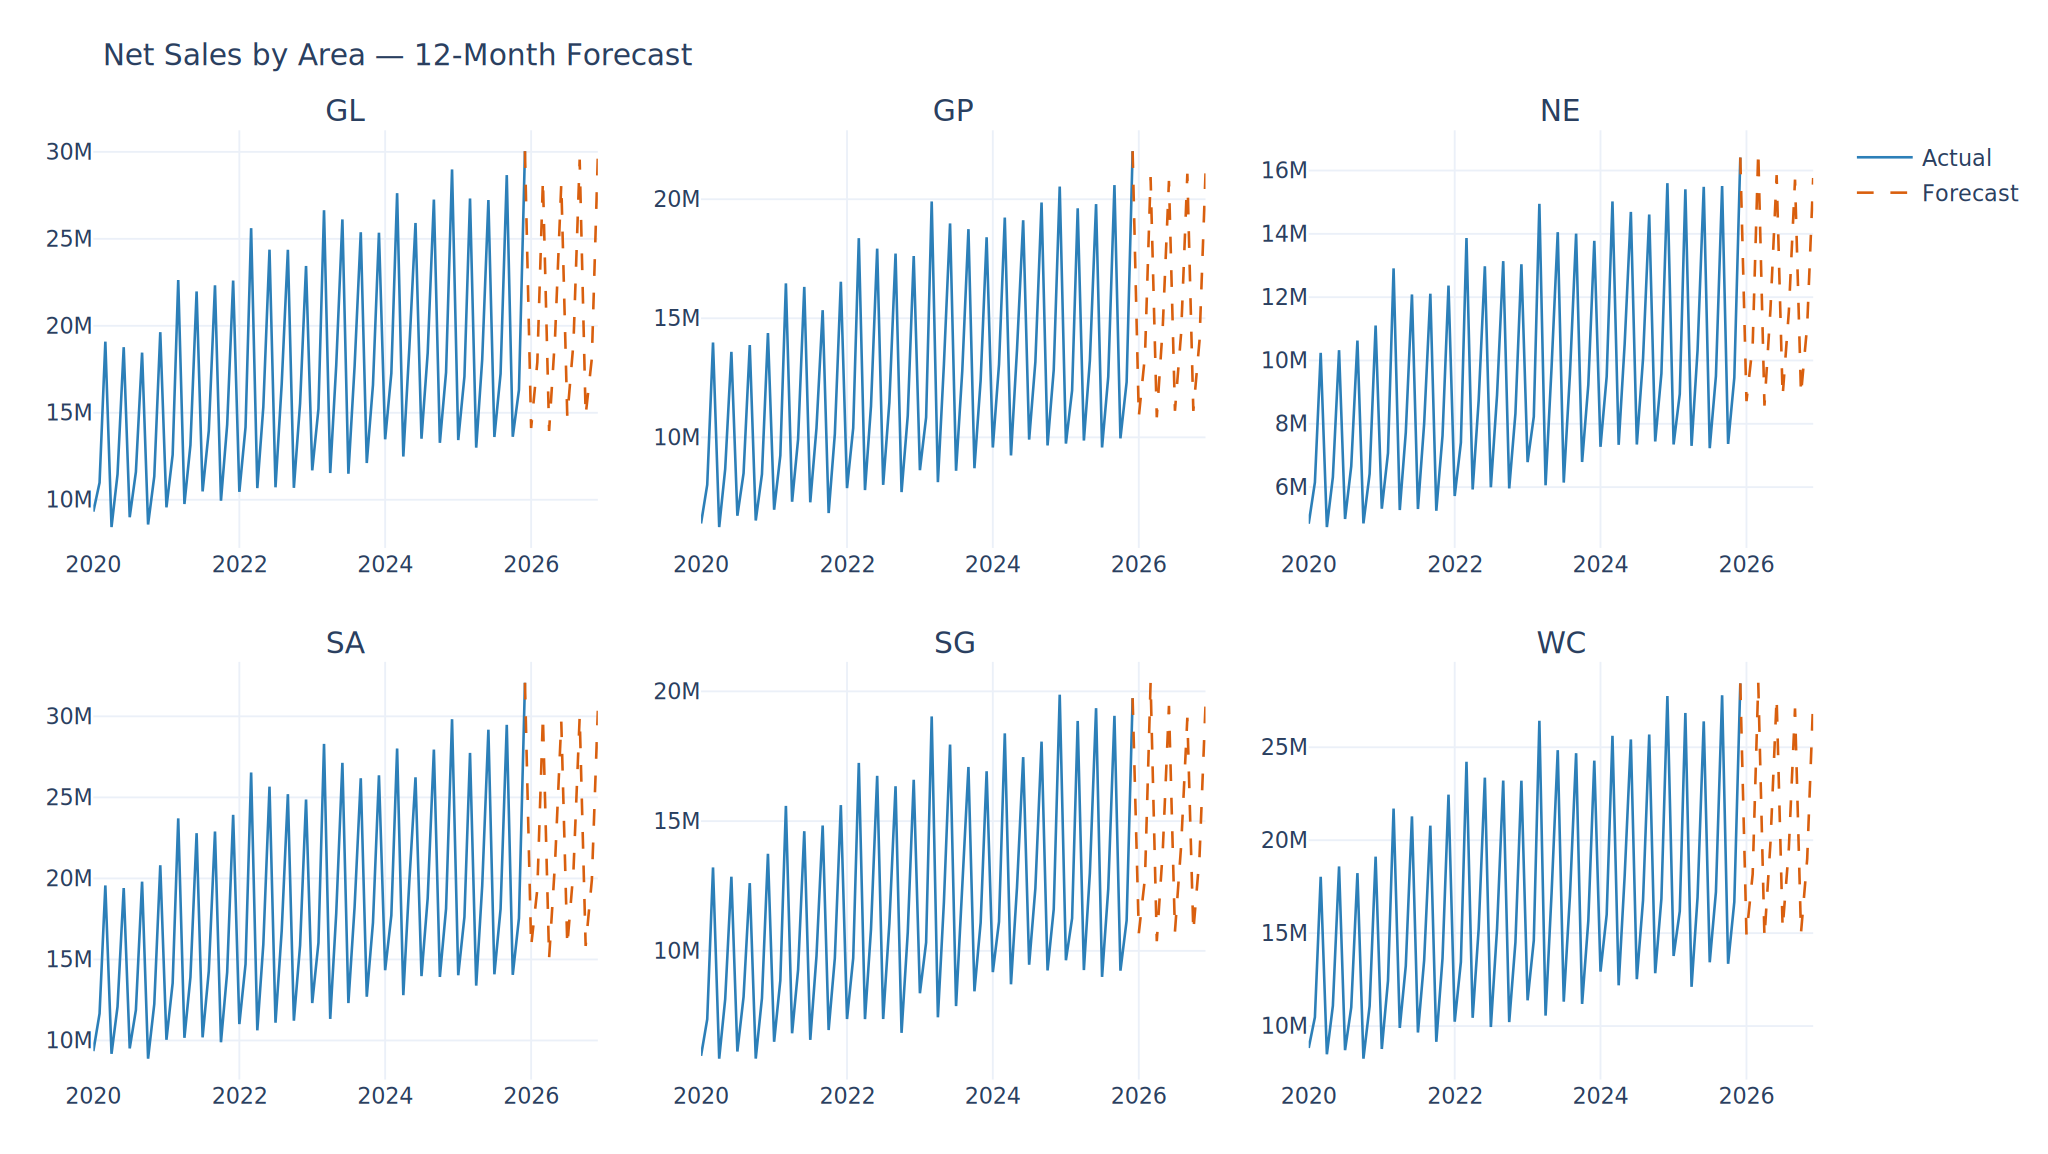

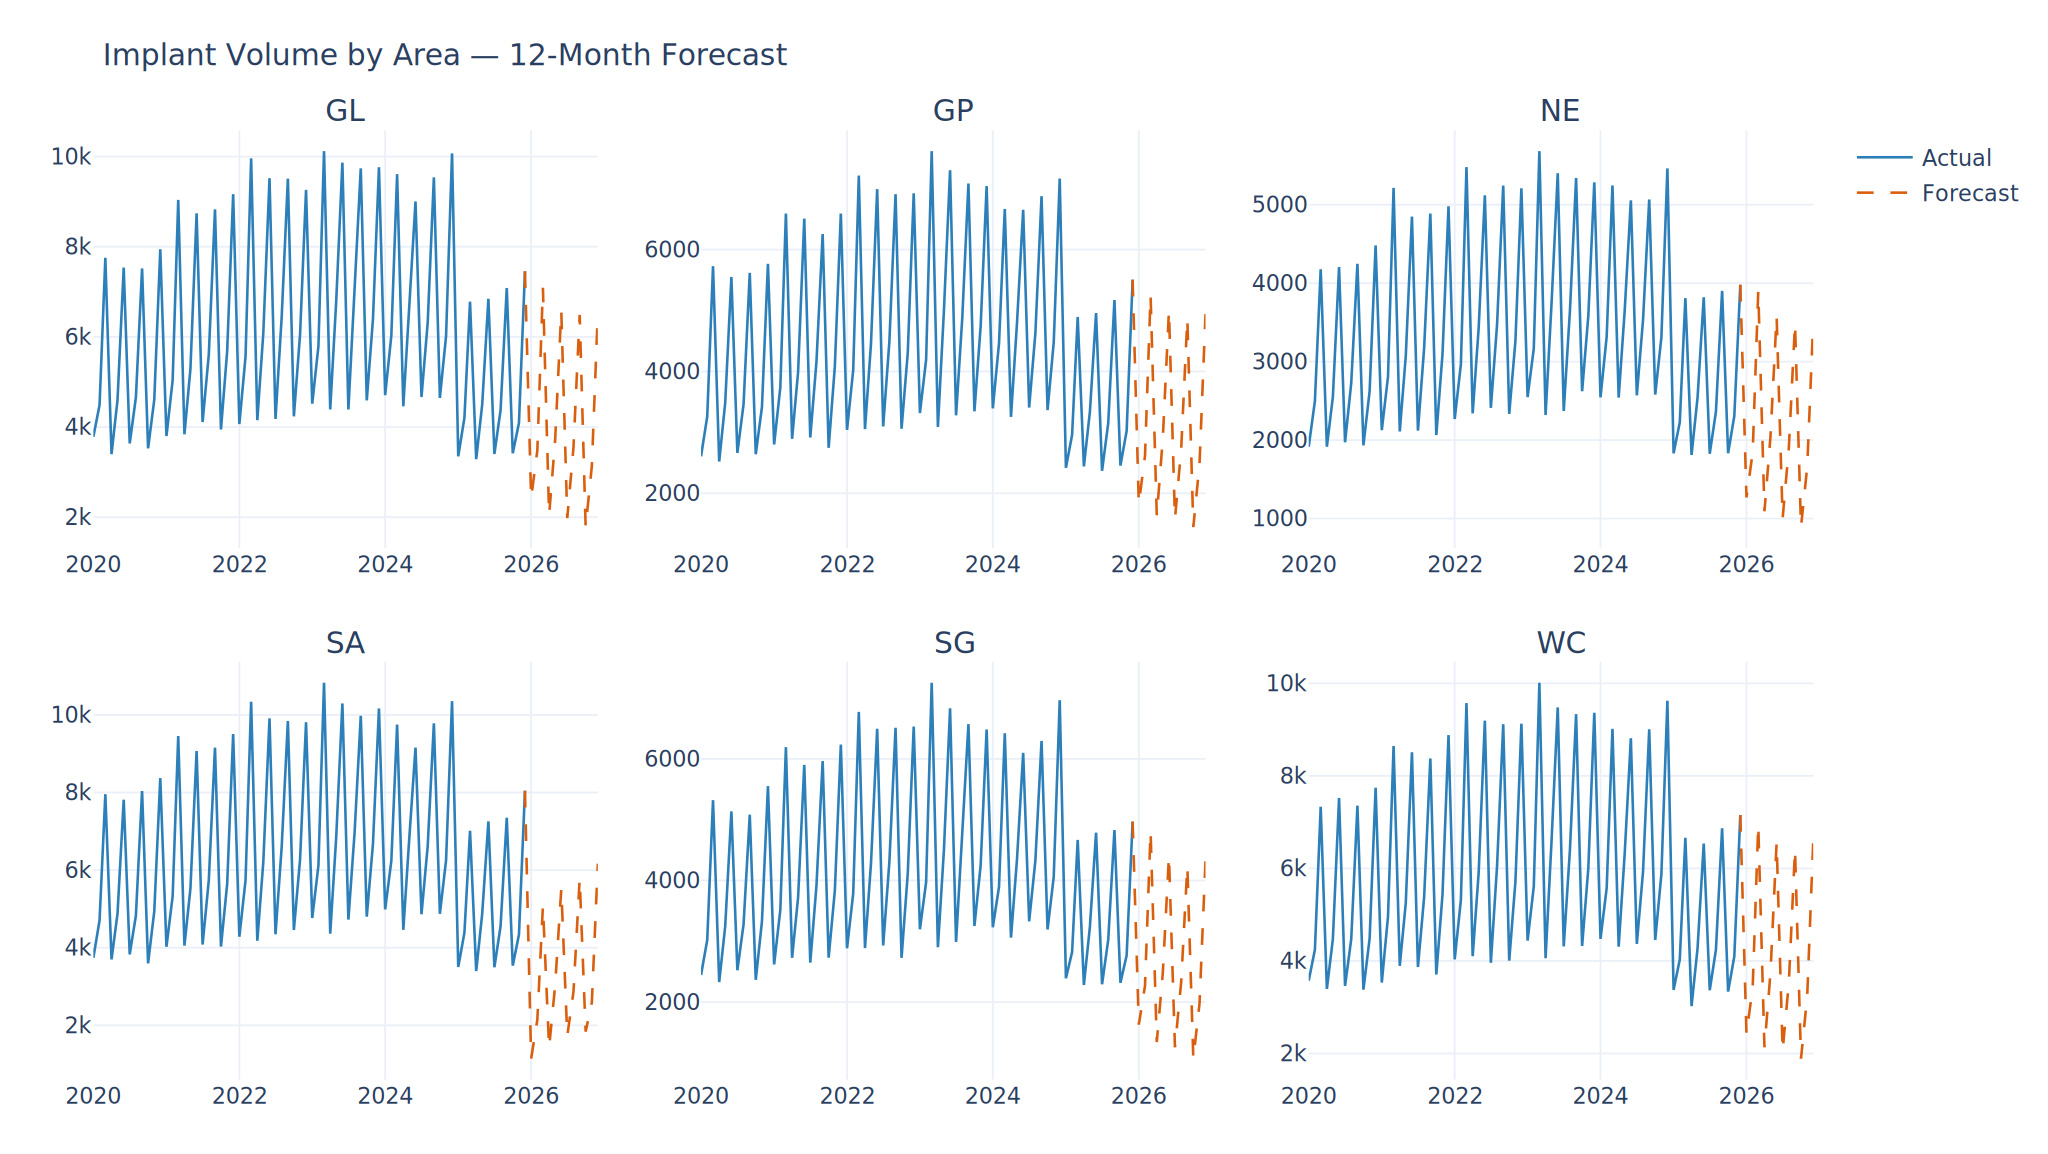

In [14]:
fc_df = pd.read_csv("outputs/forecast.csv")
fc_df["month"] = pd.to_datetime(fc_df["month"]).dt.strftime("%Y-%m-%d")  # kaleido can't serialize Timestamps

TEMPLATE = "plotly_white"
ACT_C, FC_C, BAND = "#2C7FB8", "#D95F0E", "rgba(217,95,14,0.15)"
METRIC_Y = {"net_sales": "Net Sales ($)", "volume": "Units (actual_units_sold)"}
METRIC_LBL = {"net_sales": "Net Sales", "volume": "Implant Volume"}


def plot_forecast(geo, metric):
    """Detailed single-series chart: actuals + 12-mo forecast + confidence band."""
    d = fc_df[(fc_df.geo == geo) & (fc_df.metric == metric)].sort_values("month")
    act = d[d.kind == "actual"]
    fc = d[d.kind == "forecast"]
    # bridge the gap so the forecast line connects to the last actual
    bridge = pd.concat([act.tail(1), fc])

    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=list(fc.month) + list(fc.month[::-1]),
        y=list(fc.upper) + list(fc.lower[::-1]),
        fill="toself", fillcolor=BAND, line=dict(width=0),
        name="90% interval", hoverinfo="skip"))
    fig.add_trace(go.Scatter(x=act.month, y=act.value, mode="lines",
                             name="Actual", line=dict(color=ACT_C, width=2)))
    fig.add_trace(go.Scatter(x=bridge.month, y=bridge.value, mode="lines",
                             name="Forecast", line=dict(color=FC_C, width=2, dash="dash")))
    fig.update_layout(
        template=TEMPLATE, paper_bgcolor="white", plot_bgcolor="white",
        title=f"{geo} — {METRIC_LBL[metric]} (Next 12 Months)",
        title_font=dict(size=16), xaxis_title="Month",
        yaxis_title=METRIC_Y[metric], legend_title_text="",
        margin=dict(t=60, l=80, r=30, b=60))
    return fig


def area_facets(metric):
    """2x3 small-multiples: actual + forecast for each of the 6 areas."""
    areas = ["GL", "GP", "NE", "SA", "SG", "WC"]
    fig = make_subplots(rows=2, cols=3, subplot_titles=areas,
                        horizontal_spacing=0.06, vertical_spacing=0.12)
    for i, a in enumerate(areas):
        r, c = i // 3 + 1, i % 3 + 1
        d = fc_df[(fc_df.geo == a) & (fc_df.metric == metric)].sort_values("month")
        act, fc = d[d.kind == "actual"], d[d.kind == "forecast"]
        bridge = pd.concat([act.tail(1), fc])
        fig.add_trace(go.Scatter(x=act.month, y=act.value, mode="lines",
                      line=dict(color=ACT_C, width=1.4), name="Actual",
                      showlegend=(i == 0)), row=r, col=c)
        fig.add_trace(go.Scatter(x=bridge.month, y=bridge.value, mode="lines",
                      line=dict(color=FC_C, width=1.4, dash="dash"), name="Forecast",
                      showlegend=(i == 0)), row=r, col=c)
    fig.update_layout(
        template=TEMPLATE, paper_bgcolor="white", plot_bgcolor="white", height=620,
        title=f"{METRIC_LBL[metric]} by Area — 12-Month Forecast",
        title_font=dict(size=16), legend_title_text="",
        margin=dict(t=70, l=50, r=20, b=40))
    return fig


plot_forecast("National", "net_sales").show()
plot_forecast("National", "volume").show()

area_facets("net_sales").show()
area_facets("volume").show()


## Deliverable 4 - Quota Miss Risk: Area and Region


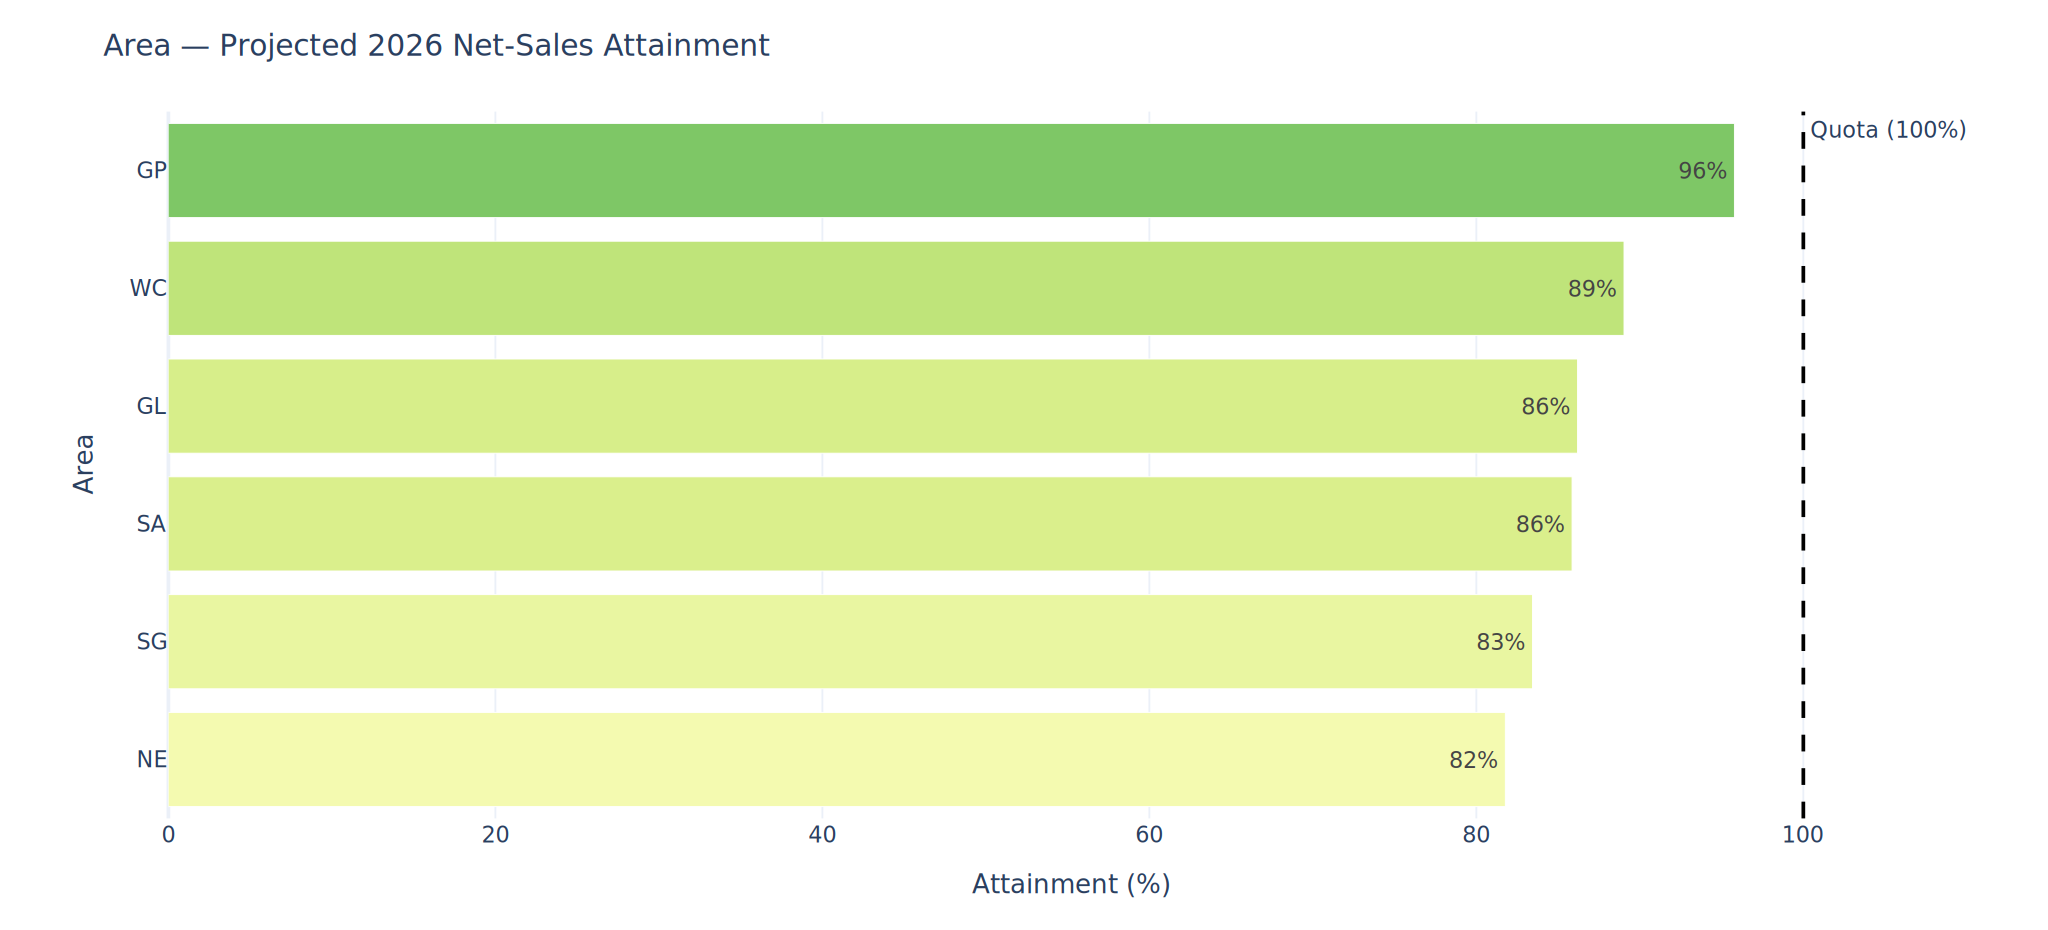

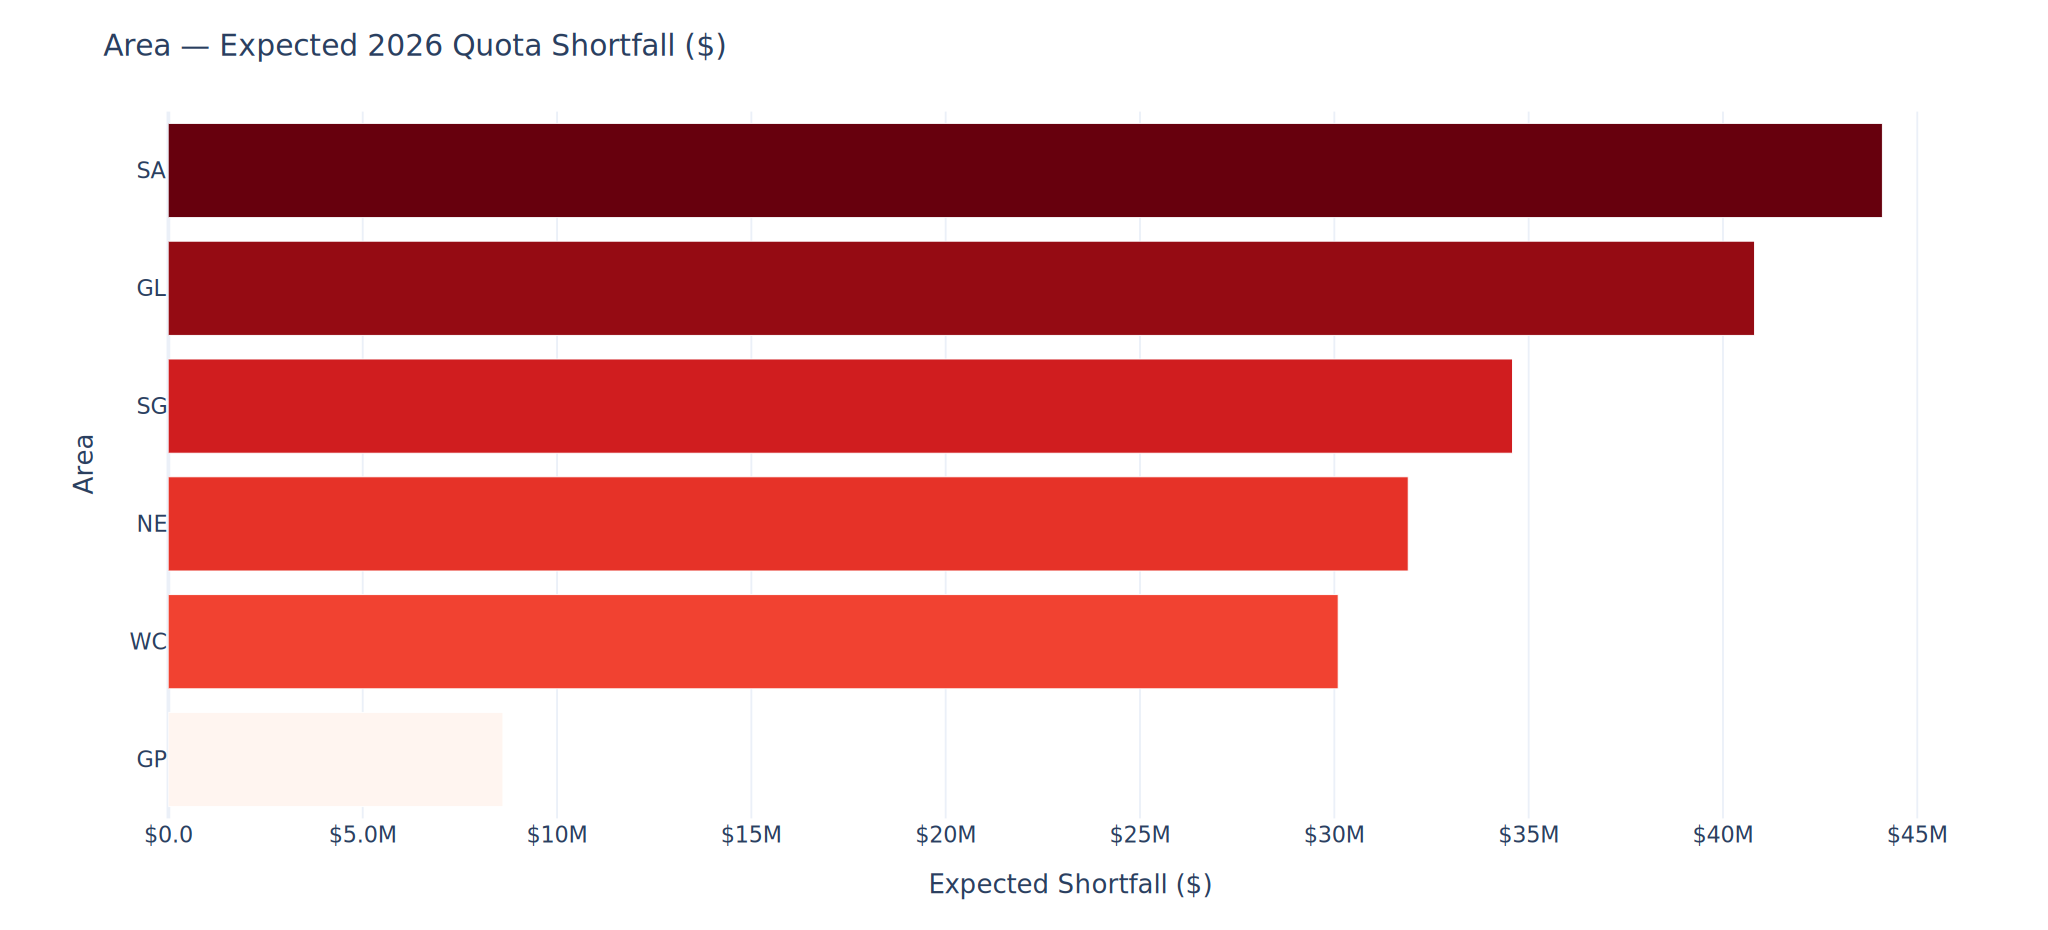

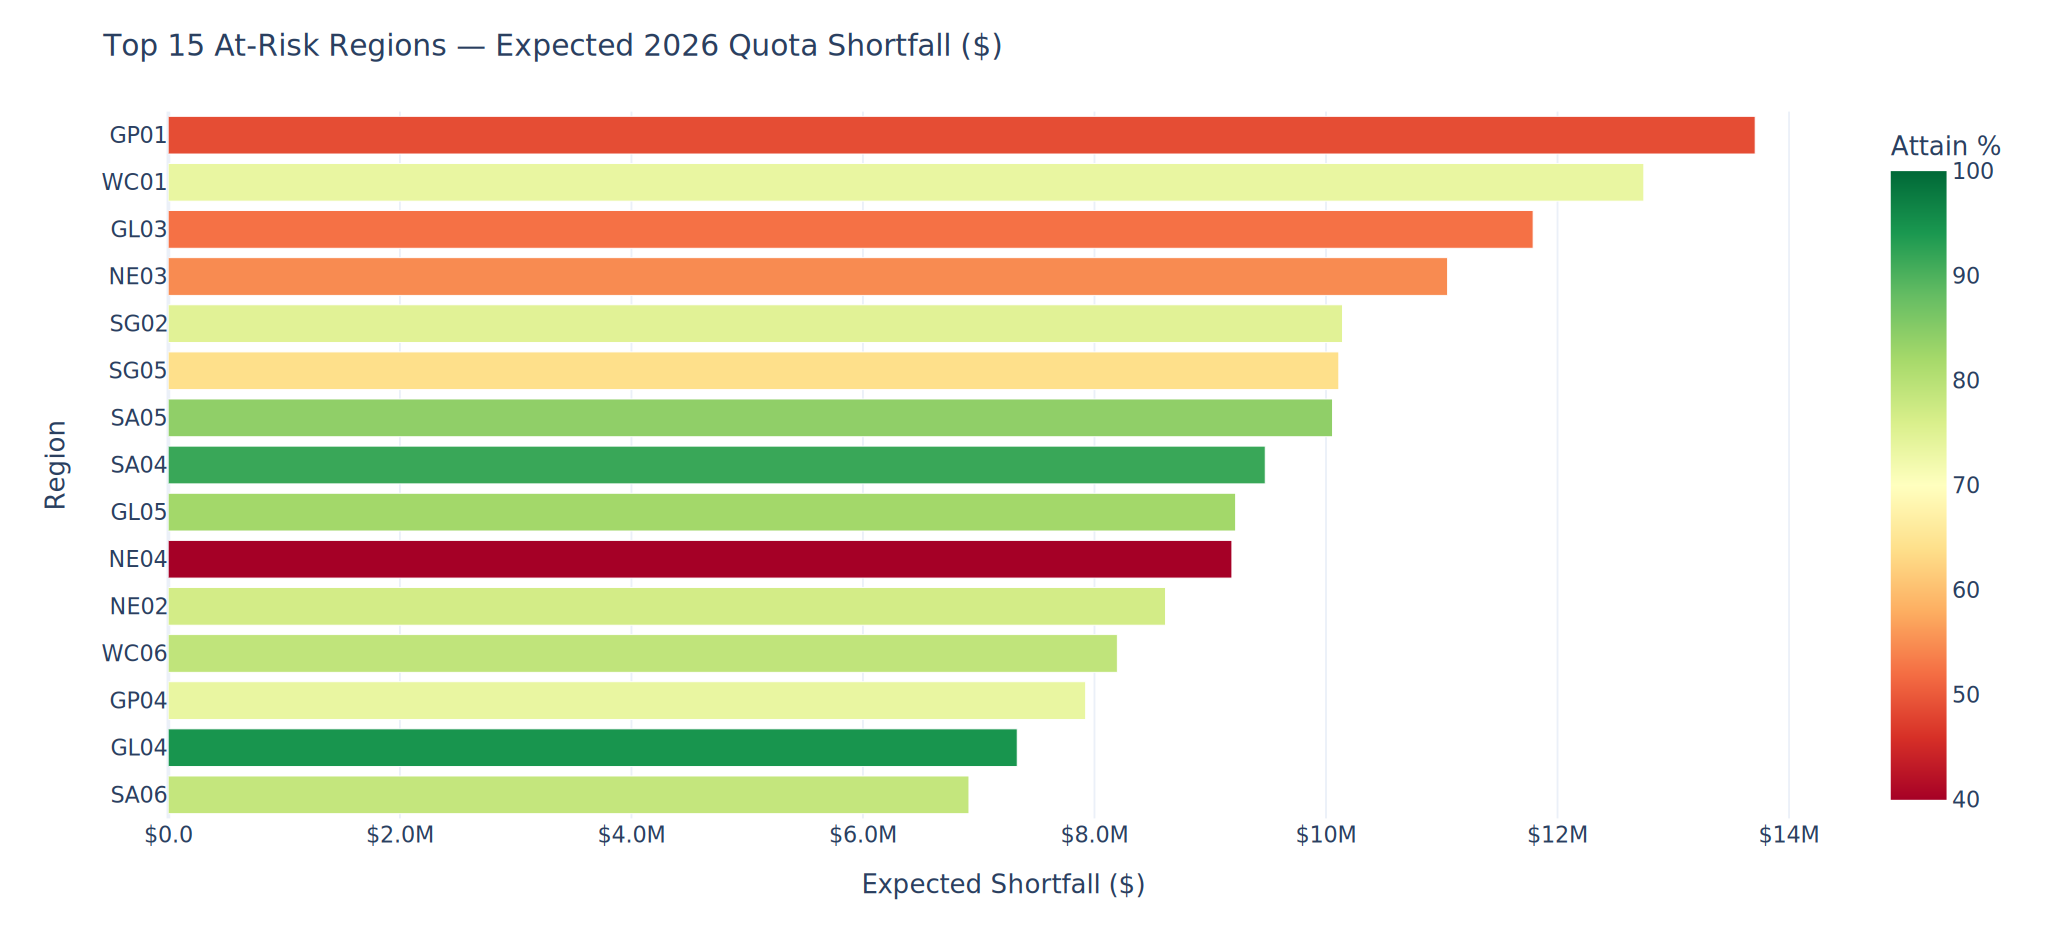

In [15]:
risk = pd.read_csv("outputs/quota_risk.csv")

TEMPLATE = "plotly_white"
def style(fig, title, xtitle, ytitle, legend=None):
    fig.update_layout(template=TEMPLATE, title=title, title_font=dict(size=16),
                    xaxis_title=xtitle, yaxis_title=ytitle,
                    paper_bgcolor="white", plot_bgcolor="white",
                    legend_title_text=legend, margin=dict(t=60, l=90, r=40, b=60))
    return fig

# --- 1) AREA: projected 2026 attainment vs the 100% quota line ---
a = risk[risk.level == "area"].sort_values("attainment_pct")
fig1 = px.bar(a, x="attainment_pct", y="area", orientation="h",
            color="attainment_pct", color_continuous_scale="RdYlGn",
            range_color=[50, 110],
            text=a["attainment_pct"].round(0).astype(int).astype(str) + "%")
fig1.add_vline(x=100, line_dash="dash", line_color="black",
                annotation_text="Quota (100%)")
fig1.update_coloraxes(showscale=False)
style(fig1, "Area — Projected 2026 Net-Sales Attainment", "Attainment (%)", "Area")
fig1.show()

# --- 2) AREA: expected dollar shortfall (the ranking driver) ---
a2 = risk[risk.level == "area"].sort_values("expected_shortfall")
fig2 = px.bar(a2, x="expected_shortfall", y="area", orientation="h",
            color="expected_shortfall", color_continuous_scale="Reds")
fig2.update_coloraxes(showscale=False)
fig2.update_xaxes(tickprefix="$", tickformat=".2s")
style(fig2, "Area — Expected 2026 Quota Shortfall ($)", "Expected Shortfall ($)", "Area")
fig2.show()

# --- 3) REGION: top 15 by expected dollar shortfall ---
r = (risk[risk.level == "region"]
    .sort_values("expected_shortfall", ascending=False).head(15)
    .sort_values("expected_shortfall"))
fig3 = px.bar(r, x="expected_shortfall", y="region_code", orientation="h",
            color="attainment_pct", color_continuous_scale="RdYlGn",
            range_color=[40, 100],
            hover_data={"attainment_pct": ":.0f", "target_2026": ":.2s",
                        "forecast_2026": ":.2s"})
fig3.update_xaxes(tickprefix="$", tickformat=".2s")
style(fig3, "Top 15 At-Risk Regions — Expected 2026 Quota Shortfall ($)",
    "Expected Shortfall ($)", "Region")
fig3.update_coloraxes(colorbar_title="Attain %")
fig3.show()


## Deliverable 5 — Top 25 High-Risk Hospitals

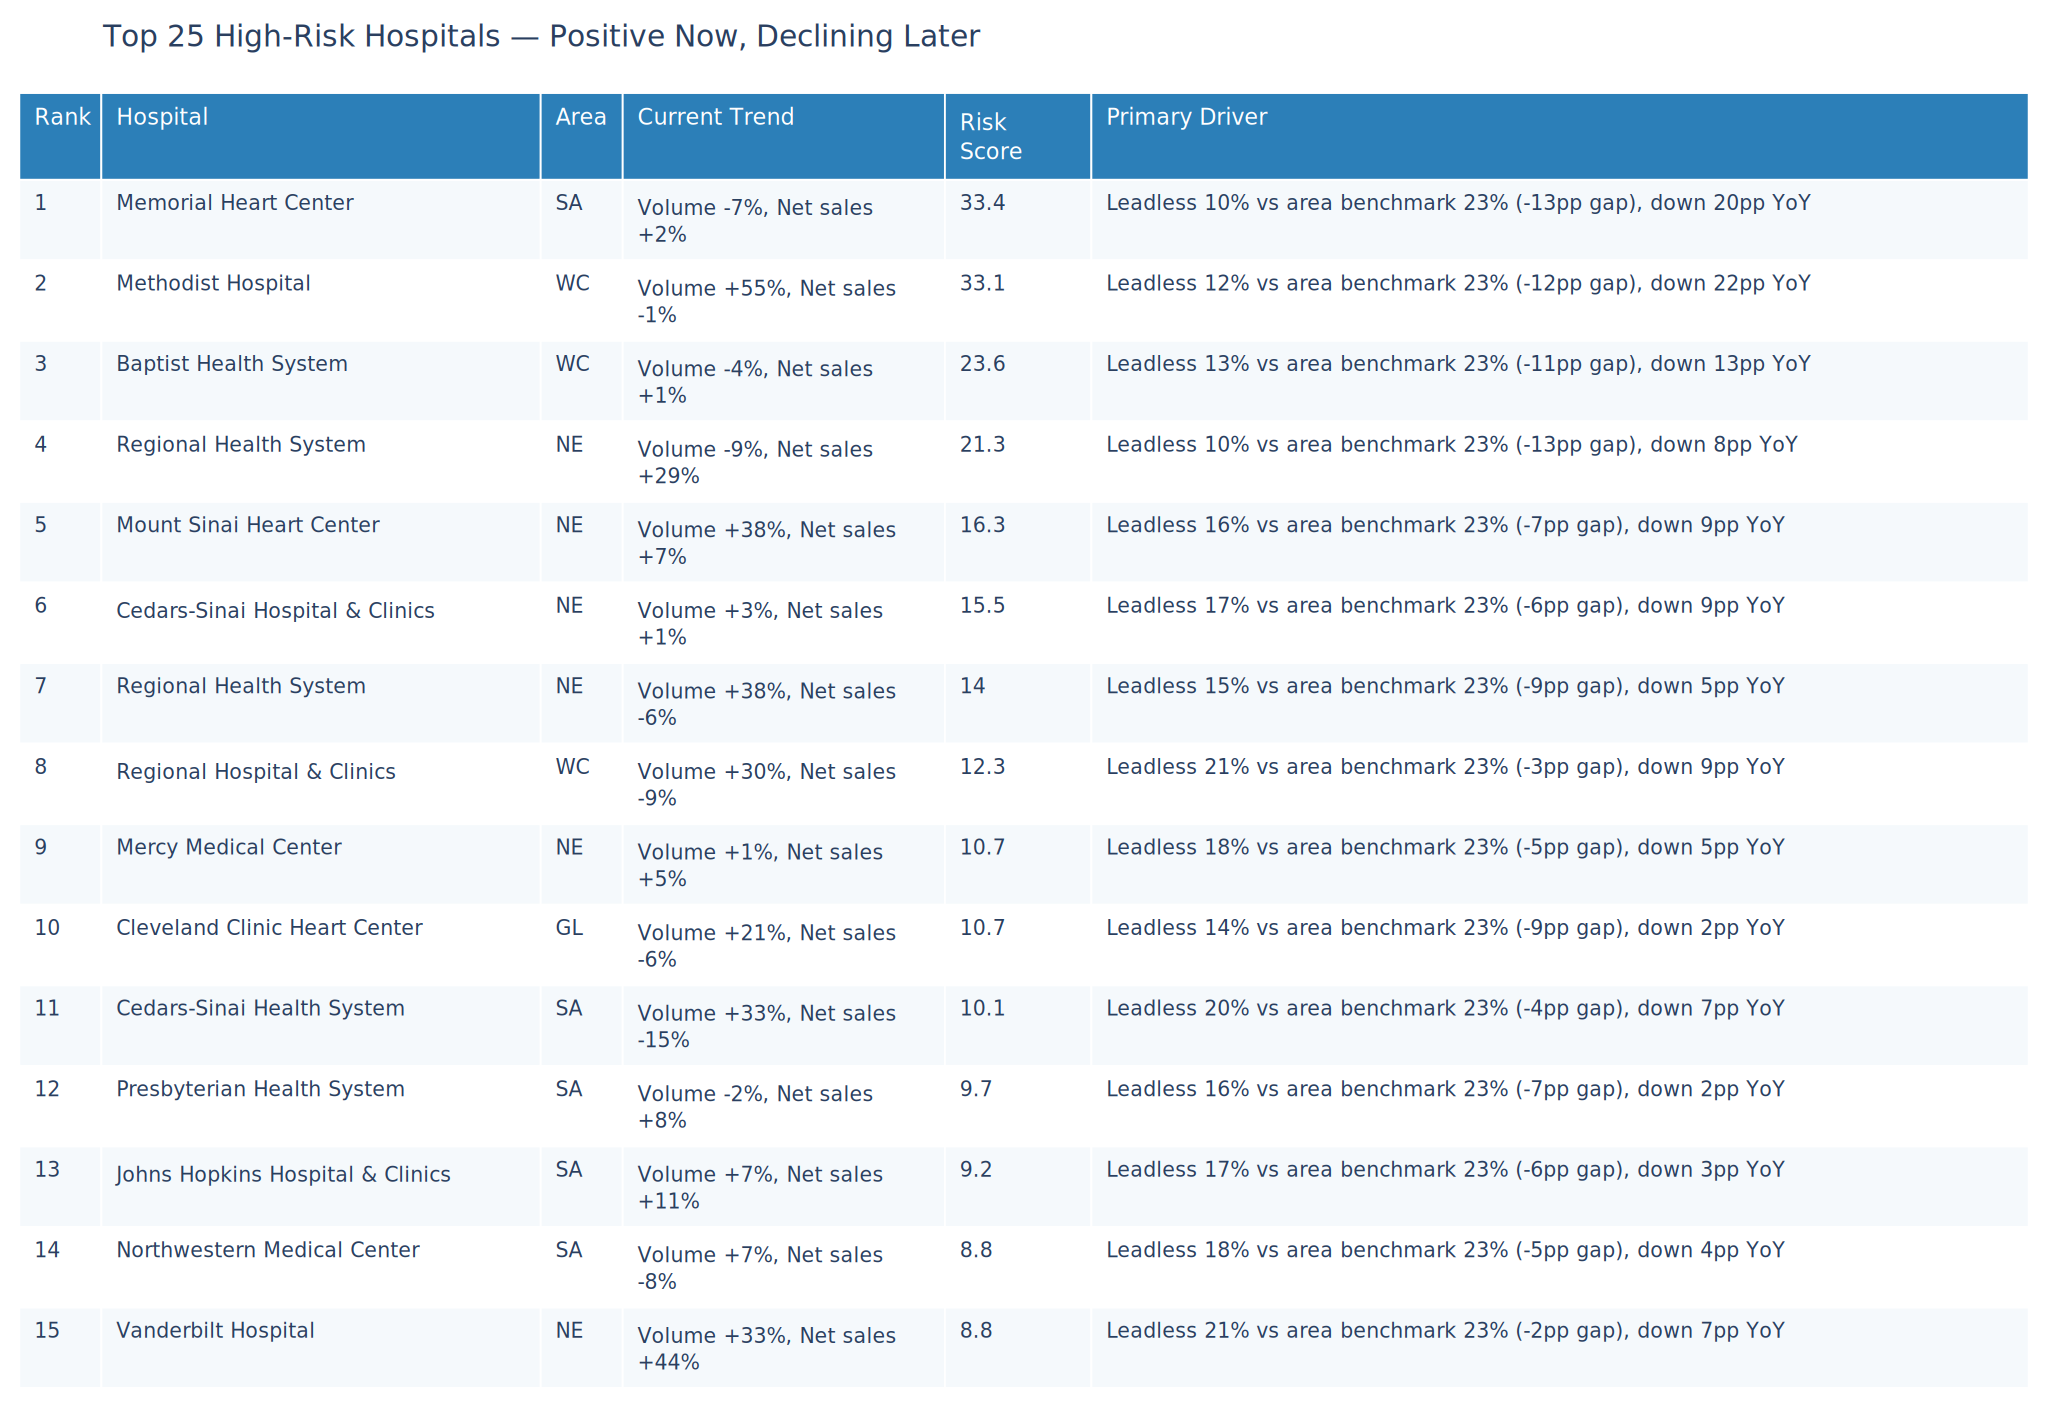

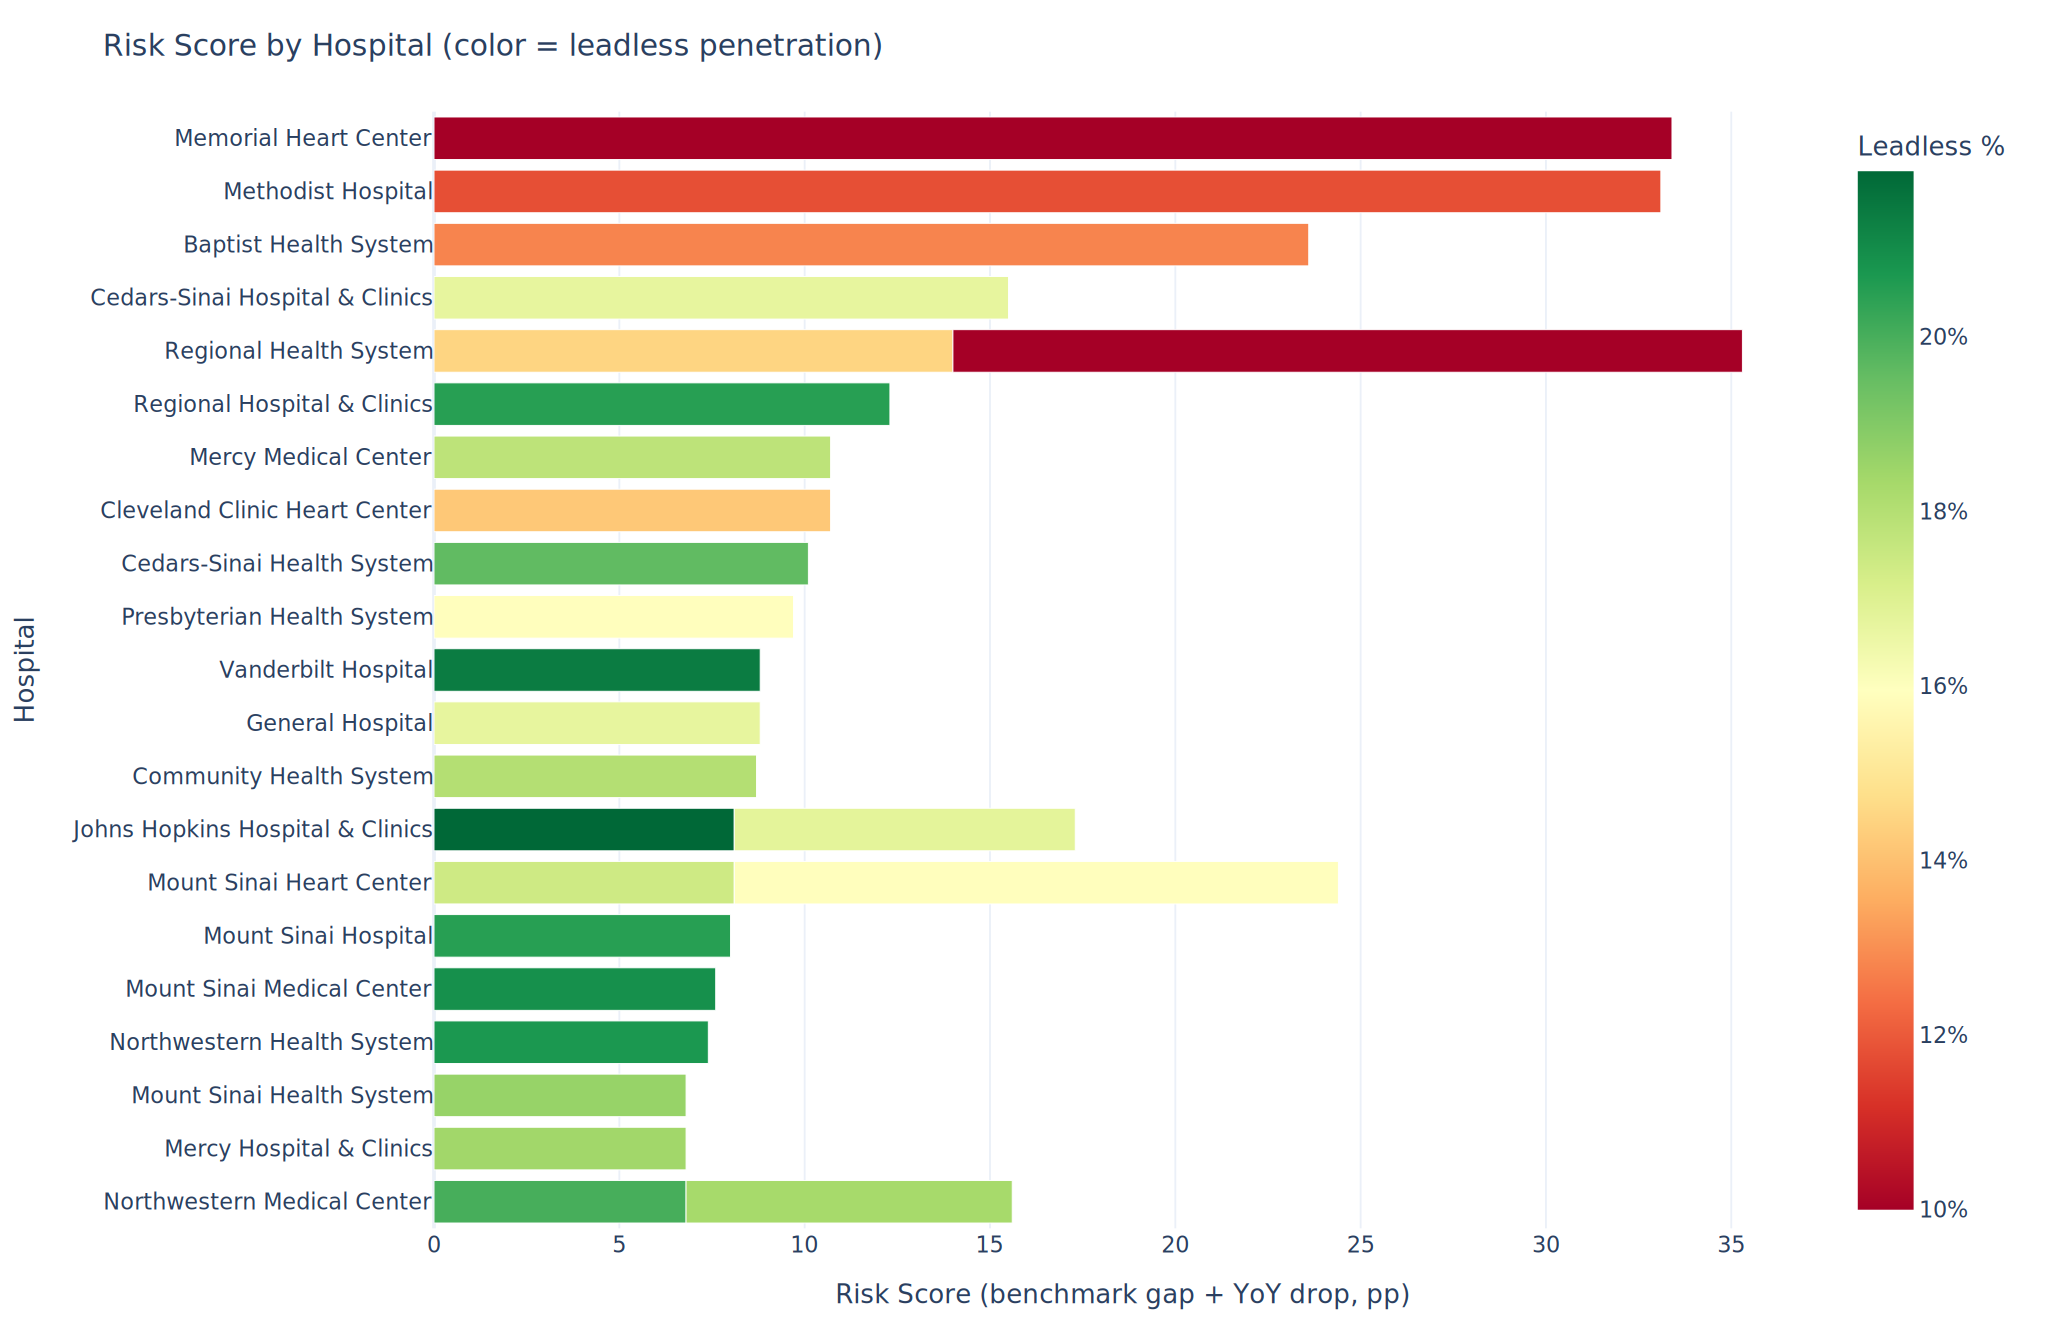

In [16]:
hr = pd.read_csv("outputs/high_risk_hospitals.csv")

cols = ["rank", "hospital_name", "area", "current_trend", "risk_score", "primary_driver"]
hdr = ["Rank", "Hospital", "Area", "Current Trend", "Risk Score", "Primary Driver"]
figt = go.Figure(go.Table(
    columnwidth=[28, 150, 28, 110, 50, 320],
    header=dict(values=hdr, fill_color="#2C7FB8", font=dict(color="white", size=12),
                align="left", height=28),
    cells=dict(values=[hr[c] for c in cols],
                fill_color=[["#f5f9fc", "white"] * 13],
                align="left", height=24, font=dict(size=11))))
figt.update_layout(title="Top 25 High-Risk Hospitals — Positive Now, Declining Later",
                    title_font=dict(size=16), margin=dict(t=50, l=10, r=10, b=10),
                    paper_bgcolor="white", height=760)
figt.show()

b = hr.sort_values("risk_score")
figb = px.bar(b, x="risk_score", y="hospital_name", orientation="h",
            color="leadless_pen", color_continuous_scale="RdYlGn",
            hover_data={"area": True, "current_trend": True, "area_benchmark": ":.0%"})
figb.update_layout(template="plotly_white", paper_bgcolor="white", plot_bgcolor="white",
                    title="Risk Score by Hospital (color = leadless penetration)",
                    title_font=dict(size=16), xaxis_title="Risk Score (benchmark gap + YoY drop, pp)",
                    yaxis_title="Hospital", height=720, margin=dict(t=60, l=200, r=40, b=60))
figb.update_coloraxes(colorbar_title="Leadless %", colorbar_tickformat=".0%")
figb.show()